# Emotion Classification from Audio Files using Deep Neural Networks and MFCCs

This notebook reproduces the approach presented in:

> **de Pinto, M. G., Polignano, M., Lops, P., & Semeraro, G. (2020).** *Emotions Understanding Model from Spoken Language using Deep Neural Networks and Mel-Frequency Cepstral Coefficients.* IEEE Conference on Evolving and Adaptive Intelligent Systems (EAIS), pp. 1-5. DOI: 10.1109/EAIS48028.2020.9122698

**Reference repository:** [marcogdepinto/emotion-classification-from-audio-files](https://github.com/marcogdepinto/emotion-classification-from-audio-files)

---

## The Problem: Why is Emotion Recognition from Speech Difficult?

Emotion recognition from speech is a challenging task that involves classifying the emotional state of a speaker from audio signals. Key difficulties include:

- **Subjectivity**: Emotions are subjective - even humans often disagree on emotional labels
- **Speaker Variability**: Different speakers express the same emotion differently
- **Cultural Differences**: Expression patterns vary across cultures and languages
- **Ambiguity**: Some emotions are inherently similar (e.g., neutral vs. calm, happy vs. surprised)

**Real-world applications:**
- Human-computer interaction and virtual assistants
- Customer service quality monitoring
- Mental health assessment tools
- Sentiment analysis in call centers

---

## The Goal

Build a classifier that can predict **8 emotion classes** from audio recordings:

| Class | Emotion | RAVDESS Code | Description |
|-------|---------|--------------|-------------|
| 0 | Neutral | 01 | No strong emotion |
| 1 | Calm | 02 | Relaxed, peaceful |
| 2 | Happy | 03 | Joy, pleasure |
| 3 | Sad | 04 | Sorrow, grief |
| 4 | Angry | 05 | Frustration, rage |
| 5 | Fearful | 06 | Anxiety, fear |
| 6 | Disgust | 07 | Revulsion, distaste |
| 7 | Surprised | 08 | Astonishment, shock |

> **Important Note from the repository:** *"The classes are encoded from 0 to 7 in the code. In the dataset, from 01 to 08. Be aware when you try. If the model predicts 0 and you are using a NEUTRAL file (01), this is correct and the expected behavior. Keras wants the predictions to start from 0 and not from 1, so the code is adjusted to cope with this requirement."*

**Target Performance:** ~80% F1 score (as achieved in the reference implementation)

---

## The Solution: MFCCs + 1D Convolutional Neural Network

The approach uses three key components:

### 1. Feature Extraction: Mel-Frequency Cepstral Coefficients (MFCCs)
- **Why MFCCs?** They capture the spectral envelope of speech, which contains emotional information
- Extract **40 MFCC coefficients** per audio frame
- **Key insight:** Take the **mean across time** → results in a fixed 40-dimensional feature vector per sample
- This aggregation step makes the problem tractable with a simple neural network

### 2. Datasets: RAVDESS + TESS
- **RAVDESS:** 1440 speech files + 1012 song files from 24 professional actors (we use speech files)
- **TESS:** 2800 samples from 2 actresses (7 emotions - no "calm" class)
- **Total:** ~5252 samples across 8 emotion classes

> **Note:** The IEEE EAIS 2020 paper uses **only RAVDESS**. The reference GitHub repository extends this work by adding TESS and using a simplified model architecture. This notebook follows the **updated GitHub repository** implementation (`neural_network.py` + `create_features.py`).

### 3. Model: 1D CNN Architecture
A simple but effective convolutional architecture that learns patterns from the MFCC features.

---

## Critical Lessons from the Reference Implementation

The reference repository documents an important lesson about avoiding data leakage:

> *"Previous versions of this work used audio features extracted from the videos of the RAVDESS dataset. This particular part of the pipeline has been removed because it was shuffling very similar files in the training and test sets, boosting accuracy of the model as a consequence (overfitting). Take a look at [this issue](https://github.com/marcogdepinto/Emotion-Classification-Ravdess/issues/11) to understand more."*

The old exploration code (in `legacy_code/data_exploration/EmotionsRecognition.ipynb`) used:
- RAVDESS only (including audio extracted from videos)
- A 2-layer Conv1D model (128 filters each, MaxPooling)
- Training for 1000 epochs with custom learning rate (lr=0.00005)
- Achieved ~90%+ validation accuracy but with **data leakage**

The **current production implementation** (`neural_network.py` + `create_features.py`) uses:
- RAVDESS audio-only files + TESS dataset
- A simpler 1-layer Conv1D model (64 filters)
- Training for 50 epochs with default RMSprop
- Achieves ~80% F1 score with **proper train/test separation**

This notebook implements the **production version** to ensure reliable, reproducible results.

In [1]:
# Setup project paths
from pathlib import Path
import sys

# Use __file__ equivalent for notebooks - find the notebook's directory
# Note: Path.cwd() may not be the notebook directory in VS Code
notebook_dir = Path(__file__).parent if '__file__' in dir() else Path.cwd()

# Try to find project root by looking for common markers
if (notebook_dir / 'notebooks').exists():
    # We're at project root
    project_root = notebook_dir
elif (notebook_dir.parent / 'data').exists():
    # We're in notebooks/ folder
    project_root = notebook_dir.parent
else:
    # Fallback: assume we're in notebooks/ and parent is project root
    project_root = notebook_dir.parent

# Verify the path is correct by checking for key directories
if not (project_root / 'data' / 'raw').exists():
    # Hard-code as fallback for VS Code execution
    project_root = Path('/Users/ilias/Documents/GitHub/sentim-app')

sys.path.insert(0, str(project_root))
print(f"Project root: {project_root}")
print(f"Data path exists: {(project_root / 'data' / 'raw').exists()}")

Project root: /Users/ilias/Documents/GitHub/sentim-app
Data path exists: True


In [2]:
import time
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# For reproducibility
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Global plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette('deep')

# Data paths - aligned with reference repo structure
RAVDESS_PATH = project_root / 'data' / 'raw' / 'audio_speech_actors_01-24'
TESS_PATH = project_root / 'data' / 'raw' / 'TESS Toronto emotional speech set data'

# Emotion labels (0-7, as per the paper)
# Classes: 0=neutral, 1=calm, 2=happy, 3=sad, 4=angry, 5=fearful, 6=disgust, 7=surprised
# Note: The paper states "the classes are encoded from 0 to 7 in the code. In the dataset, from 01 to 08."
EMOTION_LABELS = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

print(f"RAVDESS path: {RAVDESS_PATH}")
print(f"TESS path: {TESS_PATH}")

RAVDESS path: /Users/ilias/Documents/GitHub/sentim-app/data/raw/audio_speech_actors_01-24
TESS path: /Users/ilias/Documents/GitHub/sentim-app/data/raw/TESS Toronto emotional speech set data


## 1. Data Loading and Feature Extraction

### The Datasets

**RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song)**
- 24 professional actors (12 female, 12 male)
- 1440 speech files + 1012 song files (we use speech files)
- Actors speak two statements with 8 emotions at 2 intensity levels
- **Filename convention:** `MM-VV-EE-II-SS-RR-AA.wav`
  - MM = Modality (01 = full-AV, 02 = video-only, 03 = audio-only)
  - VV = Vocal channel (01 = speech, 02 = song)
  - **EE = Emotion (01-08)** ← This is what we extract
  - II = Intensity (01 = normal, 02 = strong)
  - SS = Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door")
  - RR = Repetition (01 or 02)
  - AA = Actor (01-24, odd = male, even = female)
- **Example:** `03-01-05-02-01-01-12.wav` = Audio-only, Speech, Angry (05), Strong intensity, Statement 1, Repetition 1, Actor 12 (female)

**TESS (Toronto Emotional Speech Set)**
- 2 female actresses: OAF (Older Adult Female, 64 years) and YAF (Young Adult Female, 26 years)
- 200 target words × 7 emotions × 2 speakers = 2800 files
- **Folders named by emotion:** `OAF_angry`, `YAF_happy`, etc.
- **No "calm" class** - this creates class imbalance in our combined dataset
- **Note:** Folder names have inconsistent casing (`OAF_Fear` vs `YAF_fear`) and spelling (`OAF_Pleasant_surprise` vs `YAF_pleasant_surprised`)

### Emotion Mapping

Following the reference implementation's `tess_pipeline.py`, which renames TESS files to use the RAVDESS naming convention:

| TESS Folder | RAVDESS Code | Label (0-indexed) |
|-------------|--------------|-------------------|
| neutral | 01 | 0 |
| *(no calm in TESS)* | 02 | 1 |
| happy | 03 | 2 |
| sad | 04 | 3 |
| angry | 05 | 4 |
| fear | 06 | 5 |
| disgust | 07 | 6 |
| pleasant_surprise | 08 | 7 |

From the reference `tess_pipeline.py`:
```python
label_conversion = {'01': 'neutral',
                    '03': 'happy',
                    '04': 'sad',
                    '05': 'angry',
                    '06': 'fear',
                    '07': 'disgust',
                    '08': 'ps'}  # ps = pleasant surprise
```

### Feature Extraction: MFCCs

Following the paper's exact approach from `create_features.py`:

1. **Load audio** with librosa using `kaiser_fast` resampling (fast but lower quality - acceptable for MFCCs)
2. **Extract 40 MFCCs** - Mel-Frequency Cepstral Coefficients capture spectral envelope
3. **Aggregate by taking the mean across time** → Fixed 40-dimensional vector

```python
# The key feature extraction from create_features.py:
X, sample_rate = librosa.load(os.path.join(subdir, file), res_type='kaiser_fast')
mfccs = np.mean(librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40).T, axis=0)
# Label conversion: file = int(file[7:8]) - 1  # Converts 1-8 to 0-7
```

**Why mean aggregation?**
- Audio files have different lengths → variable MFCC sequences
- Taking the mean creates a fixed-size input for the neural network
- Captures the "average spectral profile" of the utterance
- Simple but effective - more complex temporal modeling didn't improve results significantly

In [3]:
def load_ravdess_data(ravdess_path: Path):
    """
    Load RAVDESS dataset and extract features.
    
    Follows the reference implementation (create_features.py):
    - Extracts emotion label from filename (position [7:8] = 3rd segment when split by '-')
    - Labels are converted from 1-8 to 0-7 (Keras requires labels starting at 0)
    
    Filename convention: MM-VV-EE-II-SS-RR-AA.wav
    Example: 03-01-05-02-01-01-12.wav
    - MM = Modality (03 = audio-only)
    - VV = Vocal channel (01 = speech)
    - EE = Emotion (05 = angry) <- This is extracted (position [7:8] or split('-')[2])
    - II = Intensity, SS = Statement, RR = Repetition, AA = Actor
    
    Emotion codes (RAVDESS):
    01 = neutral, 02 = calm, 03 = happy, 04 = sad, 
    05 = angry, 06 = fearful, 07 = disgust, 08 = surprised
    """
    features = []
    labels = []
    
    start_time = time.time()
    
    for actor_folder in sorted(ravdess_path.iterdir()):
        if not actor_folder.is_dir() or not actor_folder.name.startswith('Actor_'):
            continue
            
        for audio_file in actor_folder.glob('*.wav'):
            try:
                # Load audio with librosa (kaiser_fast for speed)
                y, sr = librosa.load(str(audio_file), res_type='kaiser_fast')
                
                # Extract 40 MFCCs and take the mean across time
                # This is the key feature extraction as per the paper
                mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
                
                # Extract emotion from filename
                # Reference: file = int(file[7:8]) - 1 (from create_features.py)
                filename = audio_file.stem
                emotion_code = filename.split('-')[2]  # Third segment is emotion (EE)
                
                # Convert to 0-indexed label (the paper notes: "Keras wants predictions to start from 0")
                label = int(emotion_code) - 1
                
                if 0 <= label <= 7:
                    features.append(mfccs)
                    labels.append(label)
                    
            except Exception as e:
                print(f"Error processing {audio_file}: {e}")
                continue
    
    print(f"RAVDESS loaded: {len(features)} samples in {time.time() - start_time:.1f}s")
    return features, labels


def load_tess_data(tess_path: Path):
    """
    Load TESS dataset and extract features.
    
    TESS has 7 emotions (no 'calm' class - this creates dataset imbalance).
    Following the reference implementation (tess_pipeline.py), we map TESS emotions
    to the RAVDESS emotion codes:
    
    TESS folder name → RAVDESS code → Label (0-indexed)
    - neutral          → 01         → 0
    - happy            → 03         → 2  
    - sad              → 04         → 3
    - angry            → 05         → 4
    - fear             → 06         → 5
    - disgust          → 07         → 6
    - pleasant_surprise (ps) → 08   → 7
    
    Note: TESS folder names have inconsistent casing (e.g., 'OAF_Fear' vs 'YAF_fear')
    and spelling (e.g., 'OAF_Pleasant_surprise' vs 'YAF_pleasant_surprised').
    We handle these variations by normalizing to lowercase and checking for substrings.
    
    Reference: tess_pipeline.py label_conversion dictionary:
    {'01': 'neutral', '03': 'happy', '04': 'sad', '05': 'angry', 
     '06': 'fear', '07': 'disgust', '08': 'ps'}
    """
    features = []
    labels = []
    
    start_time = time.time()
    
    for emotion_folder in tess_path.iterdir():
        if not emotion_folder.is_dir():
            continue
            
        # Extract emotion from folder name (e.g., 'OAF_angry' → 'angry')
        # Normalize to lowercase to handle inconsistent casing (OAF_Fear vs YAF_fear)
        folder_name = emotion_folder.name.lower()
        
        # Determine the emotion label from folder name
        # Map TESS emotions to 0-indexed labels (matching RAVDESS codes)
        label = None
        
        # Check for 'pleasant' first (handles 'pleasant_surprise', 'pleasant_surprised')
        if 'pleasant' in folder_name:
            label = 7  # surprised (RAVDESS code 08)
        elif 'neutral' in folder_name:
            label = 0  # neutral (RAVDESS code 01)
        elif 'happy' in folder_name:
            label = 2  # happy (RAVDESS code 03)
        elif 'sad' in folder_name:
            label = 3  # sad (RAVDESS code 04)
        elif 'angry' in folder_name:
            label = 4  # angry (RAVDESS code 05)
        elif 'fear' in folder_name:
            label = 5  # fearful (RAVDESS code 06)
        elif 'disgust' in folder_name:
            label = 6  # disgust (RAVDESS code 07)
        
        if label is None:
            print(f"Warning: Could not map emotion folder: {emotion_folder.name}")
            continue
        
        for audio_file in emotion_folder.glob('*.wav'):
            try:
                # Load audio with librosa
                y, sr = librosa.load(str(audio_file), res_type='kaiser_fast')
                
                # Extract 40 MFCCs and take the mean across time
                mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
                
                features.append(mfccs)
                labels.append(label)
                
            except Exception as e:
                print(f"Error processing {audio_file}: {e}")
                continue
    
    print(f"TESS loaded: {len(features)} samples in {time.time() - start_time:.1f}s")
    return features, labels


# Load both datasets
print("Loading RAVDESS dataset...")
ravdess_features, ravdess_labels = load_ravdess_data(RAVDESS_PATH)

print("\nLoading TESS dataset...")
tess_features, tess_labels = load_tess_data(TESS_PATH)

# Combine datasets
X = np.asarray(ravdess_features + tess_features)
y = np.asarray(ravdess_labels + tess_labels)

print(f"\n{'='*50}")
print(f"Combined dataset shape: X={X.shape}, y={y.shape}")
print(f"Number of samples: {len(X)}")

# Check if data was loaded successfully
if len(X) == 0:
    print("\n⚠️  WARNING: No data was loaded!")
    print(f"   - RAVDESS path exists: {RAVDESS_PATH.exists()}")
    print(f"   - TESS path exists: {TESS_PATH.exists()}")
    print("\nPlease ensure the data folders contain .wav files:")
    print(f"   - RAVDESS: {RAVDESS_PATH}")
    print(f"   - TESS: {TESS_PATH}")
else:
    print(f"Feature dimension: {X.shape[1]} (40 MFCCs)")

Loading RAVDESS dataset...
RAVDESS loaded: 1440 samples in 27.4s

Loading TESS dataset...
TESS loaded: 2800 samples in 17.5s

Combined dataset shape: X=(4240, 40), y=(4240,)
Number of samples: 4240
Feature dimension: 40 (40 MFCCs)


Class distribution:
----------------------------------------
  neutral      (class 0):  496 samples
  calm         (class 1):  192 samples
  happy        (class 2):  592 samples
  sad          (class 3):  592 samples
  angry        (class 4):  592 samples
  fearful      (class 5):  592 samples
  disgust      (class 6):  592 samples
  surprised    (class 7):  592 samples


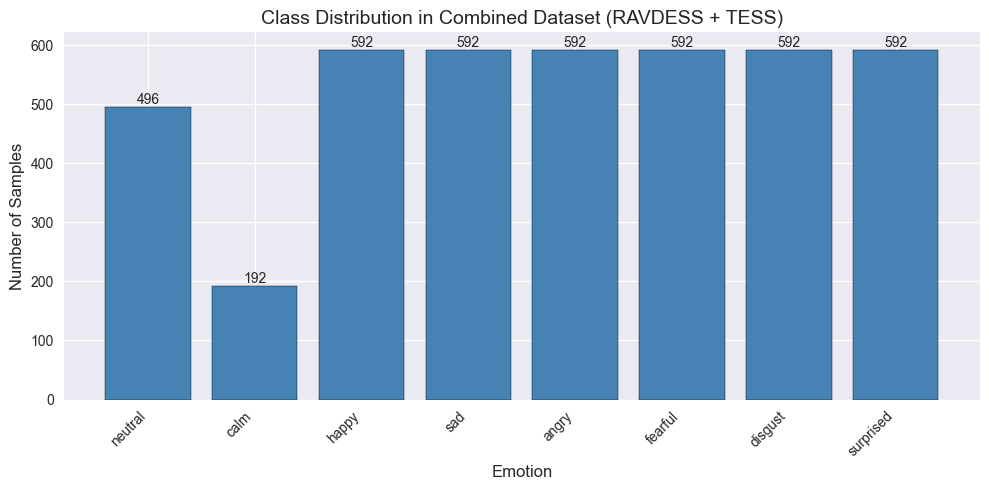


Note: 'calm' class has fewer samples because TESS doesn't include it.


In [4]:
# Analyze class distribution
print("Class distribution:")
print("-" * 40)
unique, counts = np.unique(y, return_counts=True)
for label_idx, count in zip(unique, counts):
    print(f"  {EMOTION_LABELS[label_idx]:12s} (class {label_idx}): {count:4d} samples")

# Visualize distribution
plt.figure(figsize=(10, 5))
bars = plt.bar([EMOTION_LABELS[i] for i in unique], counts, color='steelblue', edgecolor='black')
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution in Combined Dataset (RAVDESS + TESS)', fontsize=14)
plt.xticks(rotation=45, ha='right')

# Add count labels on bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{count}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nNote: 'calm' class has fewer samples because TESS doesn't include it.")

### Visualizing Audio Samples and MFCC Features

Before training, let's visualize what our data looks like. Understanding the raw audio waveforms and their MFCC representations helps build intuition about:

- **Waveforms:** Show amplitude variations over time - different emotions have different energy patterns
- **MFCCs:** The spectral features our model actually sees - patterns here are what distinguish emotions

We'll plot one sample from each emotion class to see how they differ visually.

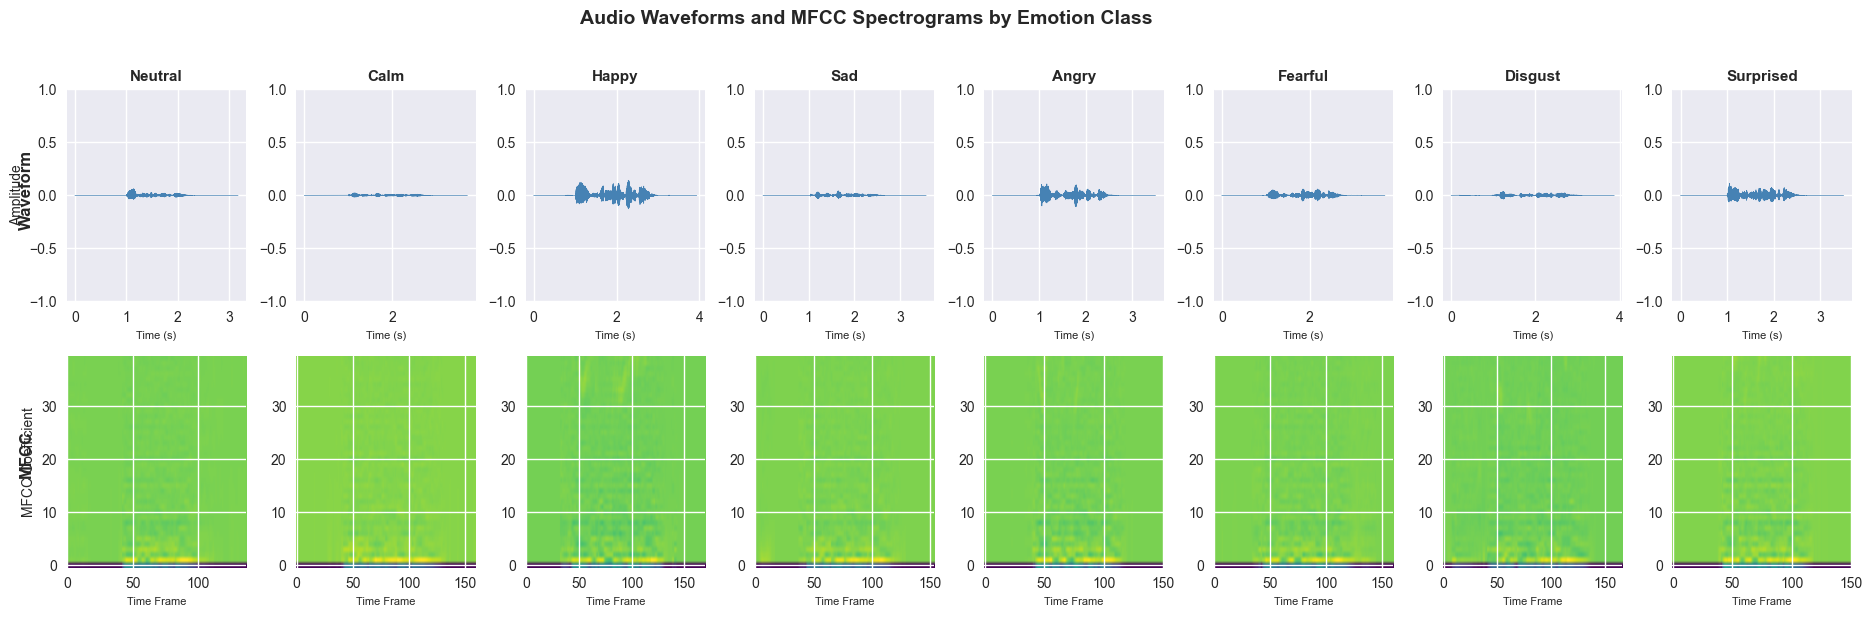


💡 Observations:
   - Waveforms show energy/intensity patterns - angry/happy tend to have higher amplitude
   - MFCCs capture spectral characteristics - notice different patterns across emotions
   - The model learns from the MEAN of these MFCC frames (40-dim vector per sample)


In [5]:
# Visualize audio waveforms and MFCC spectrograms for each emotion
# Get one sample audio file per emotion from RAVDESS for visualization

def get_sample_files_per_emotion(ravdess_path, num_samples=1):
    """Get sample audio files for each emotion class."""
    emotion_samples = {i: [] for i in range(8)}
    
    for actor_folder in sorted(ravdess_path.iterdir()):
        if not actor_folder.is_dir() or not actor_folder.name.startswith('Actor_'):
            continue
        for audio_file in actor_folder.glob('*.wav'):
            emotion_code = int(audio_file.stem.split('-')[2]) - 1
            if 0 <= emotion_code <= 7 and len(emotion_samples[emotion_code]) < num_samples:
                emotion_samples[emotion_code].append(audio_file)
    
    return emotion_samples

# Get one sample per emotion
sample_files = get_sample_files_per_emotion(RAVDESS_PATH)

# Create visualization: 2 rows (waveform, MFCC) x 8 columns (emotions)
fig, axes = plt.subplots(2, 8, figsize=(20, 6))

for emotion_idx in range(8):
    if sample_files[emotion_idx]:
        audio_path = sample_files[emotion_idx][0]
        y_audio, sr = librosa.load(str(audio_path), res_type='kaiser_fast')
        
        # Plot waveform
        axes[0, emotion_idx].plot(np.linspace(0, len(y_audio)/sr, len(y_audio)), y_audio, 
                                   color='steelblue', linewidth=0.5)
        axes[0, emotion_idx].set_title(EMOTION_LABELS[emotion_idx].capitalize(), fontsize=11, fontweight='bold')
        axes[0, emotion_idx].set_ylim(-1, 1)
        axes[0, emotion_idx].set_xlabel('Time (s)', fontsize=8)
        if emotion_idx == 0:
            axes[0, emotion_idx].set_ylabel('Amplitude', fontsize=10)
        
        # Plot MFCC spectrogram
        mfccs_full = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=40)
        img = axes[1, emotion_idx].imshow(mfccs_full, aspect='auto', origin='lower', cmap='viridis')
        axes[1, emotion_idx].set_xlabel('Time Frame', fontsize=8)
        if emotion_idx == 0:
            axes[1, emotion_idx].set_ylabel('MFCC Coefficient', fontsize=10)

# Add row labels
fig.text(0.08, 0.72, 'Waveform', ha='center', va='center', rotation='vertical', fontsize=12, fontweight='bold')
fig.text(0.08, 0.28, 'MFCC', ha='center', va='center', rotation='vertical', fontsize=12, fontweight='bold')

plt.suptitle('Audio Waveforms and MFCC Spectrograms by Emotion Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(left=0.1)
plt.show()

print("\n💡 Observations:")
print("   - Waveforms show energy/intensity patterns - angry/happy tend to have higher amplitude")
print("   - MFCCs capture spectral characteristics - notice different patterns across emotions")
print("   - The model learns from the MEAN of these MFCC frames (40-dim vector per sample)")

## 2. Data Preparation

Following the reference repository's methodology exactly:

- **Train/Test Split:** 67% training, 33% testing
- **Random State:** 42 (for reproducibility)
- **Feature Reshaping:** Expand dimensions to `(samples, 40, 1)` for Conv1D input

From `neural_network.py`:
```python
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
x_traincnn = np.expand_dims(X_train, axis=2)
x_testcnn = np.expand_dims(X_test, axis=2)
```

### Why this split ratio?

The 67/33 split is a common choice that balances:
- **Enough training data** for the model to learn patterns
- **Enough test data** for reliable evaluation
- **Consistency** with the reference implementation for comparable results

In [6]:
# Split the data (following the paper: 33% test, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.33, 
    random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Reshape for Conv1D: (samples, features, channels) = (samples, 40, 1)
# This is the key transformation from the paper
x_train_cnn = np.expand_dims(X_train, axis=2)
x_test_cnn = np.expand_dims(X_test, axis=2)

print(f"\nReshaped for CNN:")
print(f"  x_train_cnn: {x_train_cnn.shape}")
print(f"  x_test_cnn: {x_test_cnn.shape}")

Training set: 2840 samples
Test set: 1400 samples

Reshaped for CNN:
  x_train_cnn: (2840, 40, 1)
  x_test_cnn: (1400, 40, 1)


## 3. Model Architecture

### Production Model vs. Legacy Model

The reference repository contains **two different model implementations**:

#### 1. Legacy Model (`legacy_code/data_exploration/EmotionsRecognition.ipynb`)

This was used for initial exploration and **should NOT be used** due to data leakage issues:

```python
# Legacy 2-layer CNN (NOT recommended - has data leakage issues)
model = Sequential()
model.add(Conv1D(128, 5, padding='same', input_shape=(40,1)))
model.add(Activation('relu'))
model.add(Dropout(0.1))
model.add(MaxPooling1D(pool_size=(8)))
model.add(Conv1D(128, 5, padding='same'))
model.add(Activation('relu'))
model.add(Dropout(0.1))
model.add(Flatten())
model.add(Dense(8))
model.add(Activation('softmax'))
opt = keras.optimizers.rmsprop(lr=0.00005, rho=0.9, epsilon=None, decay=0.0)
```

- 2 Conv1D layers with 128 filters each
- MaxPooling between layers
- Very low dropout (0.1)
- Custom optimizer with lr=0.00005
- Trained for 1000 epochs
- Achieved ~90%+ accuracy but **with data leakage** (audio extracted from videos shuffled similar data into train/test)

#### 2. Production Model (`neural_network.py`) - **This notebook implements this**

```python
# From neural_network.py (production model - this is what we implement)
model = Sequential()
model.add(Conv1D(64, 5, padding='same', input_shape=(40, 1)))
model.add(Activation('relu'))
model.add(Dropout(0.2))
model.add(Flatten())
model.add(Dense(8))
model.add(Activation('softmax'))

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

cnn_history = model.fit(x_traincnn, y_train,
                        batch_size=16, epochs=50,
                        validation_data=(x_testcnn, y_test))
```

### Production Architecture Summary

```
Input: (40, 1) - 40 MFCCs as a 1D sequence

Conv1D(64 filters, kernel_size=5, padding='same')
→ ReLU Activation
→ Dropout(0.2)
→ Flatten
→ Dense(8, activation='softmax')

Output: 8 emotion probabilities
```

### Key Design Choices

1. **Single Conv1D Layer (64 filters):** Simpler than legacy (which used 2 layers with 128 filters). Captures local patterns in the MFCC sequence. Kernel size of 5 means each filter looks at 5 consecutive MFCC coefficients.

2. **No MaxPooling:** Unlike the legacy model, the production model skips pooling for simplicity.

3. **Higher Dropout (0.2):** Increased from 0.1 to prevent overfitting with the combined dataset.

4. **Default RMSprop:** Uses default learning rate instead of the custom `lr=0.00005` from legacy.

5. **50 epochs:** Much faster training (vs 1000 in legacy) - sufficient for convergence.

6. **Sparse Categorical Crossentropy:** Appropriate loss function when labels are integers (0-7).

### Why This Simpler Architecture Works

The simplicity is intentional and achieves ~80% F1:
- **Well-engineered features reduce model complexity needs** - MFCCs already capture relevant information
- **Fewer parameters = less overfitting** - Important with ~5000 samples
- **Fast training** - Converges in 50 epochs
- **No data leakage** - Uses only audio files (not extracted from videos)

### Comparison Summary

| Aspect | Legacy (`EmotionsRecognition.ipynb`) | Production (`neural_network.py`) |
|--------|--------------------------------------|----------------------------------|
| Conv Layers | 2 (with MaxPooling) | 1 |
| Filters | 128 | 64 |
| Dropout | 0.1 | 0.2 |
| Optimizer LR | 0.00005 | default |
| Epochs | 1000 | 50 |
| Batch Size | 16 | 16 |
| Dataset | RAVDESS only (with video audio) | RAVDESS + TESS (audio only) |
| Data Leakage | **Yes** | **No** |
| Val Accuracy | ~90%+ (inflated) | ~75-80% (realistic) |

In [7]:
# Import PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set random seed for PyTorch
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

# Check for MPS (Apple Silicon) or CUDA
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

# Define the CNN model (matching the paper's architecture)
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(EmotionCNN, self).__init__()
        # Conv1D: 64 filters, kernel_size=5, padding='same'
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(64 * 40, num_classes)  # 64 filters * 40 features
    
    def forward(self, x):
        # Input shape: (batch, 40, 1) -> need (batch, 1, 40) for PyTorch Conv1d
        x = x.permute(0, 2, 1)  # (batch, 1, 40)
        x = self.conv1(x)       # (batch, 64, 40)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.flatten(x)     # (batch, 64*40)
        x = self.fc(x)          # (batch, 8)
        return x

# Create model and move to device
model = EmotionCNN(num_classes=8).to(device)

# Display model summary
print("\nModel Architecture:")
print("=" * 60)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Using Apple Silicon GPU (MPS)

Model Architecture:
EmotionCNN(
  (conv1): Conv1d(1, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=2560, out_features=8, bias=True)
)

Total parameters: 20,872


## 4. Model Training

Training configuration from the reference `neural_network.py`:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| **Batch Size** | 16 | Small batches provide regularization effect |
| **Epochs** | 50 | Sufficient for convergence |
| **Validation** | Test set (33%) | Monitor overfitting during training |
| **Optimizer** | RMSprop (default lr) | Adaptive learning rate, good for this task |
| **Loss** | Sparse Categorical Crossentropy | Integer labels (0-7) |

### Training Expectations

Based on the reference implementation's results (from README):
- **Overall F1-score:** ~80%
- **Accuracy:** ~75-85% validation
- Training should show convergence within 50 epochs
- Some gap between train and validation accuracy is expected (natural for this dataset size)

**Note on class imbalance:** The "calm" class will have lower metrics because TESS doesn't include it, resulting in fewer training samples for that class.

In [8]:
# Prepare PyTorch DataLoaders
X_train_tensor = torch.FloatTensor(x_train_cnn)
X_test_tensor = torch.FloatTensor(x_test_cnn)
y_train_tensor = torch.LongTensor(y_train)
y_test_tensor = torch.LongTensor(y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Loss function and optimizer (matching the paper)
criterion = nn.CrossEntropyLoss()
optimizer = optim.RMSprop(model.parameters())

# Training history
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

# Training loop
print("Training the model...")
print("=" * 60)

EPOCHS = 50
for epoch in range(EPOCHS):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss = train_loss / train_total
    train_acc = train_correct / train_total
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    
    # Store history
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)
    
    print(f"Epoch {epoch+1:2d}/{EPOCHS} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

print("\nTraining complete!")

Training the model...
Epoch  1/50 - loss: 22.7509 - accuracy: 0.6081 - val_loss: 1.6046 - val_accuracy: 0.6464
Epoch  2/50 - loss: 1.9808 - accuracy: 0.6694 - val_loss: 1.0865 - val_accuracy: 0.7250
Epoch  3/50 - loss: 1.7172 - accuracy: 0.6923 - val_loss: 1.3801 - val_accuracy: 0.6771
Epoch  4/50 - loss: 1.9533 - accuracy: 0.6968 - val_loss: 1.1388 - val_accuracy: 0.7014
Epoch  5/50 - loss: 1.7044 - accuracy: 0.7137 - val_loss: 12.2708 - val_accuracy: 0.3793
Epoch  6/50 - loss: 1.6244 - accuracy: 0.7257 - val_loss: 0.9982 - val_accuracy: 0.7286
Epoch  7/50 - loss: 1.3702 - accuracy: 0.7338 - val_loss: 1.5374 - val_accuracy: 0.6836
Epoch  8/50 - loss: 1.3471 - accuracy: 0.7363 - val_loss: 1.1313 - val_accuracy: 0.7414
Epoch  9/50 - loss: 1.4900 - accuracy: 0.7479 - val_loss: 1.6939 - val_accuracy: 0.6821
Epoch 10/50 - loss: 1.4849 - accuracy: 0.7482 - val_loss: 2.4880 - val_accuracy: 0.6250
Epoch 11/50 - loss: 1.5634 - accuracy: 0.7394 - val_loss: 1.1483 - val_accuracy: 0.7350
Epoch 12

## 5. Training Visualization

Plotting loss and accuracy curves to monitor training progress and detect overfitting.

**What to look for:**
- **Loss:** Both curves should decrease; validation loss should not increase significantly
- **Accuracy:** Both curves should increase; gap between train and validation indicates overfitting
- **Convergence:** Curves should plateau by the end of training

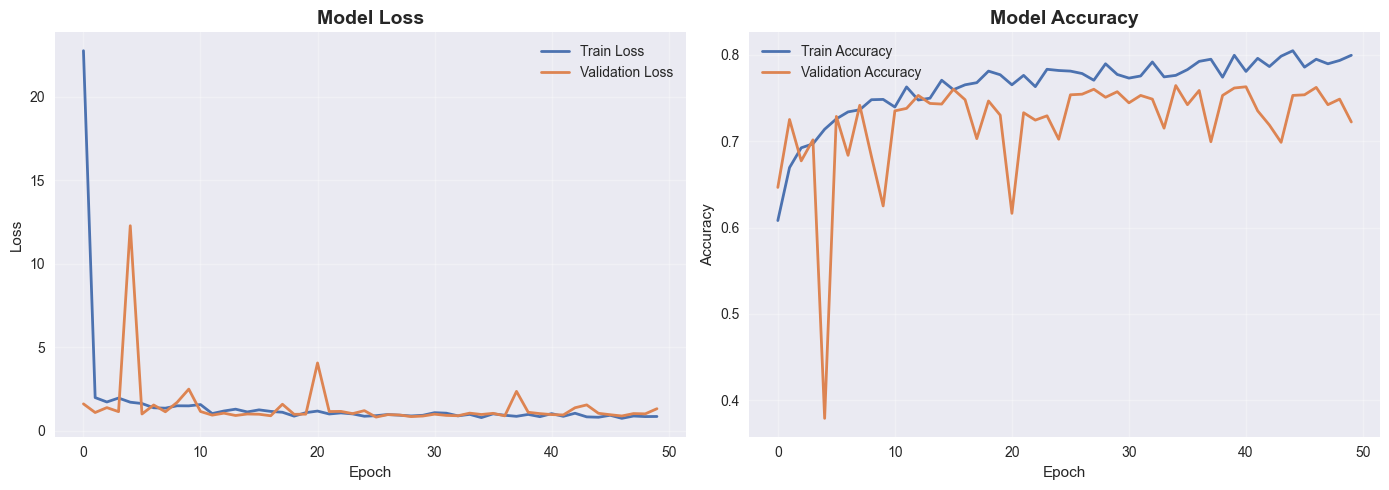


Final Training Loss: 0.8494
Final Validation Loss: 1.3145
Final Training Accuracy: 0.7993
Final Validation Accuracy: 0.7221


In [9]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy plot
axes[1].plot(history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Training Loss: {history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history['val_accuracy'][-1]:.4f}")

## 6. Model Evaluation

### Classification Report

The classification report provides detailed per-class metrics:

| Metric | Description |
|--------|-------------|
| **Precision** | Of all predictions for a class, how many were correct? |
| **Recall** | Of all actual samples of a class, how many were found? |
| **F1-Score** | Harmonic mean of precision and recall |
| **Support** | Number of samples in each class |

**Expected Results (from the paper):**
- Overall F1-score: ~80%
- **Calm** class will have lower metrics (fewer samples, similar to neutral)
- **Neutral vs Calm** confusion is common (subjectively similar emotions)

In [10]:
# Generate predictions with PyTorch
model.eval()
with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    y_pred = model(X_test_device)
    y_pred_classes = torch.argmax(y_pred, dim=1).cpu().numpy()

# Classification Report
print("Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_classes, target_names=EMOTION_LABELS, digits=3))

Classification Report
              precision    recall  f1-score   support

     neutral      0.902     0.854     0.878       151
        calm      0.400     0.087     0.143        69
       happy      0.862     0.676     0.758       185
         sad      0.954     0.639     0.765       194
       angry      0.737     0.833     0.782       192
     fearful      0.873     0.738     0.800       187
     disgust      0.441     0.929     0.598       212
   surprised      0.910     0.629     0.744       210

    accuracy                          0.722      1400
   macro avg      0.760     0.673     0.683      1400
weighted avg      0.784     0.722     0.724      1400



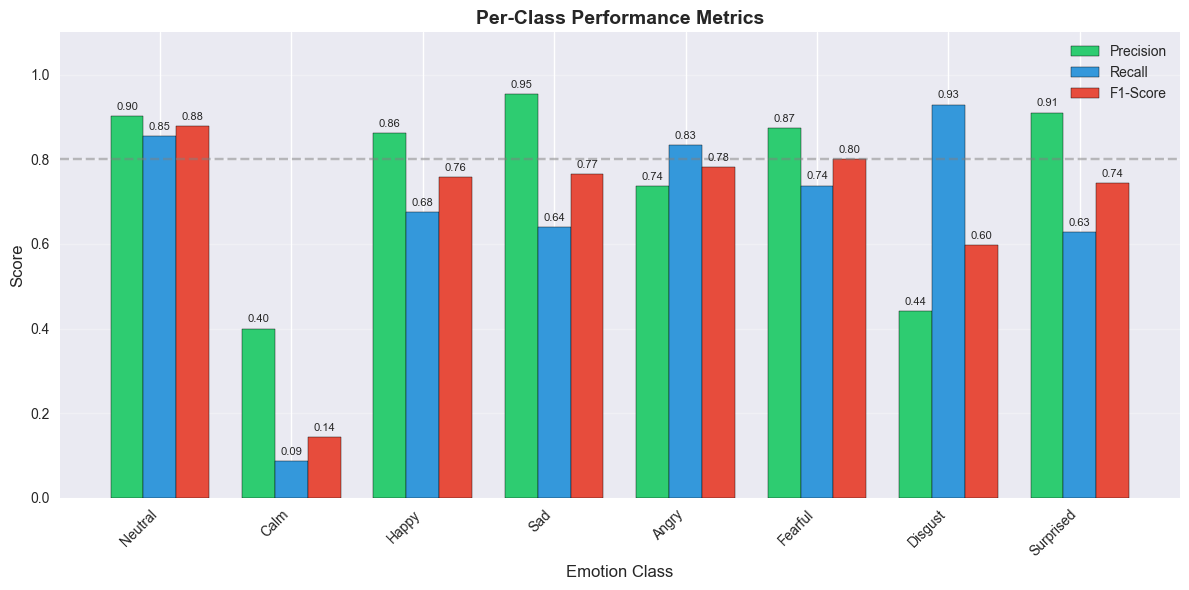


📊 Performance Summary:
   Best performing class:  Neutral (F1=0.878)
   Worst performing class: Calm (F1=0.143)
   Average F1-score:       0.683


In [11]:
# Per-class metrics visualization (clearer than reading the classification report)
from sklearn.metrics import precision_recall_fscore_support

# Calculate per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_classes, average=None)

# Create grouped bar chart
x = np.arange(len(EMOTION_LABELS))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, precision, width, label='Precision', color='#2ecc71', edgecolor='black')
bars2 = ax.bar(x, recall, width, label='Recall', color='#3498db', edgecolor='black')
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='#e74c3c', edgecolor='black')

ax.set_xlabel('Emotion Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([e.capitalize() for e in EMOTION_LABELS], rotation=45, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(0, 1.1)
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='80% target')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n📊 Performance Summary:")
print(f"   Best performing class:  {EMOTION_LABELS[np.argmax(f1)].capitalize()} (F1={np.max(f1):.3f})")
print(f"   Worst performing class: {EMOTION_LABELS[np.argmin(f1)].capitalize()} (F1={np.min(f1):.3f})")
print(f"   Average F1-score:       {np.mean(f1):.3f}")

### Confusion Matrix

The confusion matrix reveals the model's systematic errors. Understanding these patterns is crucial for:
- Identifying which emotions are hardest to distinguish
- Understanding model limitations for deployment
- Guiding future improvements

**Expected Confusion Patterns (from the paper):**
- **Neutral ↔ Calm:** Often confused because they're semantically similar
- **Happy ↔ Surprised:** Both have positive/high-arousal characteristics
- **Sad ↔ Fearful:** Both are negative emotions with similar vocal characteristics

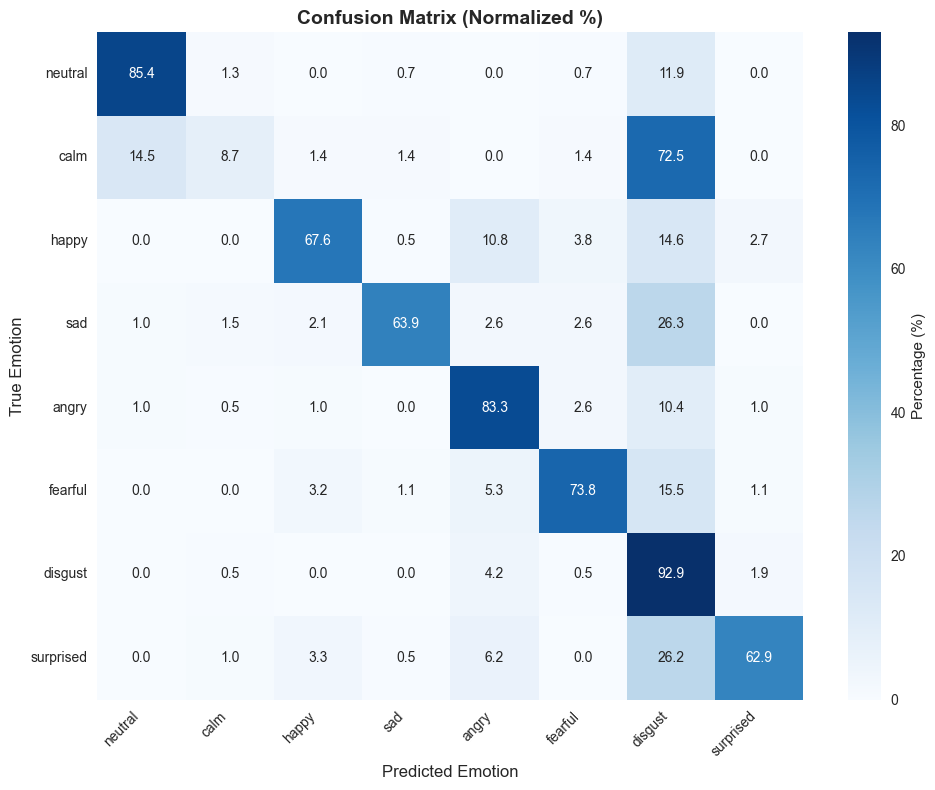


Raw Confusion Matrix (counts):
------------------------------------------------------------
[[129   2   0   1   0   1  18   0]
 [ 10   6   1   1   0   1  50   0]
 [  0   0 125   1  20   7  27   5]
 [  2   3   4 124   5   5  51   0]
 [  2   1   2   0 160   5  20   2]
 [  0   0   6   2  10 138  29   2]
 [  0   1   0   0   9   1 197   4]
 [  0   2   7   1  13   0  55 132]]


In [12]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Normalize for percentage display
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
            cbar_kws={'label': 'Percentage (%)'})
plt.xlabel('Predicted Emotion', fontsize=12)
plt.ylabel('True Emotion', fontsize=12)
plt.title('Confusion Matrix (Normalized %)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Also show raw counts
print("\nRaw Confusion Matrix (counts):")
print("-" * 60)
print(cm)

## 7. Save the Model

Save the trained model for deployment and inference.

The reference implementation (`neural_network.py`) saves the model in **Keras H5 format**:
```python
model_name = 'Emotion_Voice_Detection_Model.h5'
model.save(model_path)
```

For inference, the model is loaded in `live_predictions.py`:
```python
import keras
self.loaded_model = keras.models.load_model(path)
```

The prediction pipeline then:
1. Loads an audio file with librosa
2. Extracts MFCCs (same as training)
3. Expands dimensions for Conv1D input
4. Calls `model.predict()` to get class probabilities

In [13]:
# Save the model in PyTorch format
model_save_path = project_root / 'models' / 'Emotion_Voice_Detection_Model.pt'
model_save_path.parent.mkdir(parents=True, exist_ok=True)

# Save both model architecture and weights
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history
}, str(model_save_path))
print(f"Model saved to: {model_save_path}")

# Verify the model can be loaded
print("\nVerifying model can be loaded...")
loaded_model = EmotionCNN(num_classes=8)
checkpoint = torch.load(str(model_save_path), weights_only=False)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
print(f"Model loaded successfully!")

Model saved to: /Users/ilias/Documents/GitHub/sentim-app/models/Emotion_Voice_Detection_Model.pt

Verifying model can be loaded...
Model loaded successfully!


## 8. Making Predictions (Inference Example)

The reference repository's `live_predictions.py` shows how to use the trained model for inference. Here's the prediction pipeline:

```python
# From live_predictions.py
def make_predictions(self):
    data, sampling_rate = librosa.load(self.file)
    mfccs = np.mean(librosa.feature.mfcc(y=data, sr=sampling_rate, n_mfcc=40).T, axis=0)
    x = np.expand_dims(mfccs, axis=2)
    x = np.expand_dims(x, axis=0)  # Add batch dimension
    predictions = self.loaded_model.predict(x)
```

**Key steps:**
1. Load audio file with librosa
2. Extract MFCCs (same preprocessing as training)
3. Expand dimensions: `(40,)` → `(40, 1)` → `(1, 40, 1)`
4. Get predictions (probabilities for each of 8 classes)
5. Convert class index to emotion label

Example Prediction on Test Sample
True emotion: happy (class 2)
Predicted emotion: angry (class 4)
Confidence: 67.59%


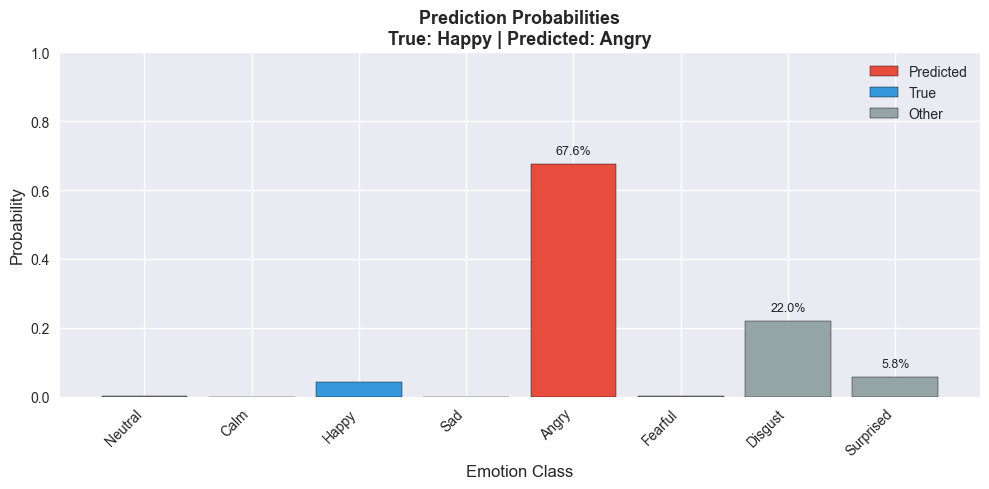


📋 All probabilities:
  neutral     :  0.10% 
  calm        :  0.01% 
  happy       :  4.30% ◄ TRUE
  sad         :  0.01% 
  angry       : 67.59% ◄ PREDICTED
  fearful     :  0.11% 
  disgust     : 22.05% 
  surprised   :  5.83% 


In [14]:
def predict_emotion(audio_path, model, device):
    """
    Predict emotion from an audio file.
    
    Following the reference implementation (live_predictions.py):
    1. Load audio with librosa
    2. Extract 40 MFCCs, averaged across time
    3. Reshape for model input
    4. Get predictions
    
    Parameters:
        audio_path: Path to the audio file
        model: Trained PyTorch model
        device: torch device (cpu/cuda/mps)
    
    Returns:
        Predicted emotion label and confidence scores
    """
    # Load audio
    data, sampling_rate = librosa.load(str(audio_path))
    
    # Extract MFCCs (same as training)
    mfccs = np.mean(librosa.feature.mfcc(y=data, sr=sampling_rate, n_mfcc=40).T, axis=0)
    
    # Reshape for model: (40,) -> (1, 40, 1)
    x = np.expand_dims(mfccs, axis=2)  # (40, 1)
    x = np.expand_dims(x, axis=0)       # (1, 40, 1)
    x = torch.FloatTensor(x).to(device)
    
    # Get predictions
    model.eval()
    with torch.no_grad():
        outputs = model(x)
        probs = torch.softmax(outputs, dim=1)
        predicted_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][predicted_class].item()
    
    return EMOTION_LABELS[predicted_class], confidence, probs[0].cpu().numpy()


# Example: Test on a sample from the test set
print("Example Prediction on Test Sample")
print("=" * 50)

# Use a random sample from test set to demonstrate
sample_idx = 0
sample_mfccs = torch.FloatTensor(x_test_cnn[sample_idx:sample_idx+1]).to(device)
sample_true_label = y_test[sample_idx]

model.eval()
with torch.no_grad():
    outputs = model(sample_mfccs)
    pred_probs = torch.softmax(outputs, dim=1)[0].cpu().numpy()
    pred_class = np.argmax(pred_probs)
    pred_confidence = pred_probs[pred_class]

print(f"True emotion: {EMOTION_LABELS[sample_true_label]} (class {sample_true_label})")
print(f"Predicted emotion: {EMOTION_LABELS[pred_class]} (class {pred_class})")
print(f"Confidence: {pred_confidence:.2%}")

# Visualize prediction probabilities as a bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if i == pred_class else '#3498db' if i == sample_true_label else '#95a5a6' 
          for i in range(len(EMOTION_LABELS))]
bars = ax.bar([e.capitalize() for e in EMOTION_LABELS], pred_probs, color=colors, edgecolor='black')

ax.set_xlabel('Emotion Class', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title(f'Prediction Probabilities\nTrue: {EMOTION_LABELS[sample_true_label].capitalize()} | Predicted: {EMOTION_LABELS[pred_class].capitalize()}', 
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.0)
plt.xticks(rotation=45, ha='right')

# Add probability labels on bars
for bar, prob in zip(bars, pred_probs):
    if prob > 0.05:  # Only label bars with >5% probability
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{prob:.1%}', ha='center', va='bottom', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', edgecolor='black', label='Predicted'),
                   Patch(facecolor='#3498db', edgecolor='black', label='True'),
                   Patch(facecolor='#95a5a6', edgecolor='black', label='Other')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

print(f"\n📋 All probabilities:")
for i, (emotion, prob) in enumerate(zip(EMOTION_LABELS, pred_probs)):
    marker = "◄ PREDICTED" if i == pred_class else ("◄ TRUE" if i == sample_true_label else "")
    print(f"  {emotion:12s}: {prob:6.2%} {marker}")

## 8.1 Inference Time Benchmarking

For real-world deployment in applications like virtual assistants or call center analysis, **inference latency** is critical. Let's measure:

1. **Model inference time** — How fast is the CNN forward pass?
2. **End-to-end prediction time** — Including MFCC preprocessing
3. **Batch inference throughput** — Processing multiple samples at once

We run multiple iterations to account for variance (warm-up effects, system load, etc.).

🔬 Inference Time Benchmarking
Device: mps
Number of runs: 100 (+ 10 warmup runs)

📊 Single Sample Inference (Model Forward Pass Only)
------------------------------------------------------------
  Mean:   0.0667 ms
  Std:    0.0110 ms
  Min:    0.0566 ms
  Max:    0.1289 ms
  Median: 0.0640 ms
  → Throughput: ~14998 predictions/second

📊 Batch Inference Performance
------------------------------------------------------------
Batch Size   Mean (ms)    Per Sample (ms)  Throughput     
------------------------------------------------------------
1            0.0619       0.0619           16166          /s
8            0.0663       0.0083           120642         /s
16           0.0683       0.0043           234312         /s
32           0.0721       0.0023           443997         /s
64           0.0696       0.0011           920157         /s

📊 End-to-End Prediction Time (MFCC Extraction + Model Inference)
------------------------------------------------------------
  Audio file: 03-01

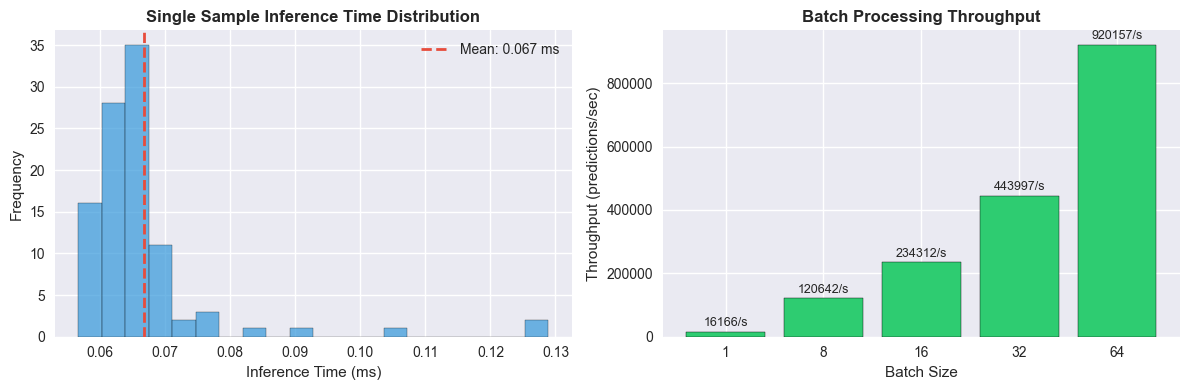


✅ Inference benchmarking complete!


In [15]:
import time

def benchmark_inference(model, sample_input, n_runs=100, warmup_runs=10):
    """
    Benchmark model inference time over multiple runs.
    
    Parameters:
        model: Trained PyTorch model
        sample_input: Input tensor for inference
        n_runs: Number of timed runs
        warmup_runs: Number of warmup runs (not timed)
    
    Returns:
        Dictionary with timing statistics
    """
    model.eval()
    times = []
    
    # Warmup runs (not timed) - allows JIT compilation, cache warming, etc.
    with torch.no_grad():
        for _ in range(warmup_runs):
            _ = model(sample_input)
    
    # Timed runs
    with torch.no_grad():
        for _ in range(n_runs):
            start = time.perf_counter()
            _ = model(sample_input)
            end = time.perf_counter()
            times.append((end - start) * 1000)  # Convert to milliseconds
    
    return {
        'mean_ms': np.mean(times),
        'std_ms': np.std(times),
        'min_ms': np.min(times),
        'max_ms': np.max(times),
        'median_ms': np.median(times),
        'times': times
    }

# ============================================================
# 1. Single Sample Inference Time (Model Only)
# ============================================================
print("🔬 Inference Time Benchmarking")
print("=" * 60)
print(f"Device: {device}")
print(f"Number of runs: 100 (+ 10 warmup runs)\n")

# Prepare single sample
single_sample = torch.FloatTensor(x_test_cnn[0:1]).to(device)

single_stats = benchmark_inference(model, single_sample, n_runs=100, warmup_runs=10)

print("📊 Single Sample Inference (Model Forward Pass Only)")
print("-" * 60)
print(f"  Mean:   {single_stats['mean_ms']:.4f} ms")
print(f"  Std:    {single_stats['std_ms']:.4f} ms")
print(f"  Min:    {single_stats['min_ms']:.4f} ms")
print(f"  Max:    {single_stats['max_ms']:.4f} ms")
print(f"  Median: {single_stats['median_ms']:.4f} ms")
print(f"  → Throughput: ~{1000/single_stats['mean_ms']:.0f} predictions/second")

# ============================================================
# 2. Batch Inference Time
# ============================================================
batch_sizes = [1, 8, 16, 32, 64]
batch_results = []

print("\n📊 Batch Inference Performance")
print("-" * 60)
print(f"{'Batch Size':<12} {'Mean (ms)':<12} {'Per Sample (ms)':<16} {'Throughput':<15}")
print("-" * 60)

for batch_size in batch_sizes:
    # Create batch (repeat samples if needed)
    n_repeats = (batch_size // len(x_test_cnn)) + 1
    batch_data = np.tile(x_test_cnn, (n_repeats, 1, 1))[:batch_size]
    batch_tensor = torch.FloatTensor(batch_data).to(device)
    
    stats = benchmark_inference(model, batch_tensor, n_runs=50, warmup_runs=5)
    per_sample = stats['mean_ms'] / batch_size
    throughput = 1000 / per_sample
    
    batch_results.append({
        'batch_size': batch_size,
        'total_ms': stats['mean_ms'],
        'per_sample_ms': per_sample,
        'throughput': throughput
    })
    
    print(f"{batch_size:<12} {stats['mean_ms']:<12.4f} {per_sample:<16.4f} {throughput:<15.0f}/s")

# ============================================================
# 3. End-to-End Prediction Time (with MFCC extraction)
# ============================================================
print("\n📊 End-to-End Prediction Time (MFCC Extraction + Model Inference)")
print("-" * 60)

# Use a sample audio file from the dataset
benchmark_audio_files = list(RAVDESS_PATH.glob("Actor_01/*.wav"))[:1]
if benchmark_audio_files:
    benchmark_audio_path = benchmark_audio_files[0]
    
    # Benchmark end-to-end prediction
    e2e_times = []
    mfcc_times = []
    model_times = []
    
    for _ in range(20):  # Fewer runs since file I/O is involved
        # Total time
        start_total = time.perf_counter()
        
        # MFCC extraction
        start_mfcc = time.perf_counter()
        data, sampling_rate = librosa.load(str(benchmark_audio_path))
        mfccs = np.mean(librosa.feature.mfcc(y=data, sr=sampling_rate, n_mfcc=40).T, axis=0)
        x = np.expand_dims(mfccs, axis=1)  # (40,) -> (40, 1)
        x = np.expand_dims(x, axis=0)       # (40, 1) -> (1, 40, 1)
        x = torch.FloatTensor(x).to(device)
        end_mfcc = time.perf_counter()
        
        # Model inference
        start_model = time.perf_counter()
        with torch.no_grad():
            outputs = model(x)
            _ = torch.softmax(outputs, dim=1)
        end_model = time.perf_counter()
        
        end_total = time.perf_counter()
        
        mfcc_times.append((end_mfcc - start_mfcc) * 1000)
        model_times.append((end_model - start_model) * 1000)
        e2e_times.append((end_total - start_total) * 1000)
    
    print(f"  Audio file: {benchmark_audio_path.name}")
    print(f"  MFCC extraction:  {np.mean(mfcc_times):.2f} ± {np.std(mfcc_times):.2f} ms ({np.mean(mfcc_times)/np.mean(e2e_times)*100:.1f}% of total)")
    print(f"  Model inference:  {np.mean(model_times):.2f} ± {np.std(model_times):.2f} ms ({np.mean(model_times)/np.mean(e2e_times)*100:.1f}% of total)")
    print(f"  End-to-end total: {np.mean(e2e_times):.2f} ± {np.std(e2e_times):.2f} ms")
    print(f"\n  💡 Note: MFCC extraction is typically the bottleneck, not the CNN!")
else:
    print("  ⚠️ No sample audio files found for end-to-end benchmarking")

# ============================================================
# 4. Visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Single sample inference time distribution
axes[0].hist(single_stats['times'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(single_stats['mean_ms'], color='#e74c3c', linestyle='--', linewidth=2, label=f"Mean: {single_stats['mean_ms']:.3f} ms")
axes[0].set_xlabel('Inference Time (ms)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Single Sample Inference Time Distribution', fontsize=12, fontweight='bold')
axes[0].legend()

# Plot 2: Batch throughput scaling
batch_sizes_plot = [r['batch_size'] for r in batch_results]
throughputs = [r['throughput'] for r in batch_results]
axes[1].bar(range(len(batch_sizes_plot)), throughputs, color='#2ecc71', edgecolor='black')
axes[1].set_xticks(range(len(batch_sizes_plot)))
axes[1].set_xticklabels(batch_sizes_plot)
axes[1].set_xlabel('Batch Size', fontsize=11)
axes[1].set_ylabel('Throughput (predictions/sec)', fontsize=11)
axes[1].set_title('Batch Processing Throughput', fontsize=12, fontweight='bold')

# Add value labels on bars
for i, (bs, tp) in enumerate(zip(batch_sizes_plot, throughputs)):
    axes[1].text(i, tp + max(throughputs)*0.02, f'{tp:.0f}/s', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✅ Inference benchmarking complete!")

## 9. Data Augmentation Experiment: Background Noise

**Why add background noise?**

Real-world audio rarely occurs in perfect silence. Adding background noise during training helps the model:

1. **Generalize better** to noisy real-world environments (call centers, outdoor recordings, etc.)
2. **Reduce overfitting** by creating varied training samples
3. **Learn robust features** that focus on emotional patterns rather than clean audio artifacts

**Implementation:**
- Generate Gaussian (white) noise at a controlled Signal-to-Noise Ratio (SNR)
- Apply noise to existing training samples to create augmented versions
- Train a new model and compare performance with the baseline

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| SNR Range | 15-25 dB | Moderate noise that doesn't overwhelm speech |
| Augmentation | Training set only | Test set stays clean for fair evaluation |

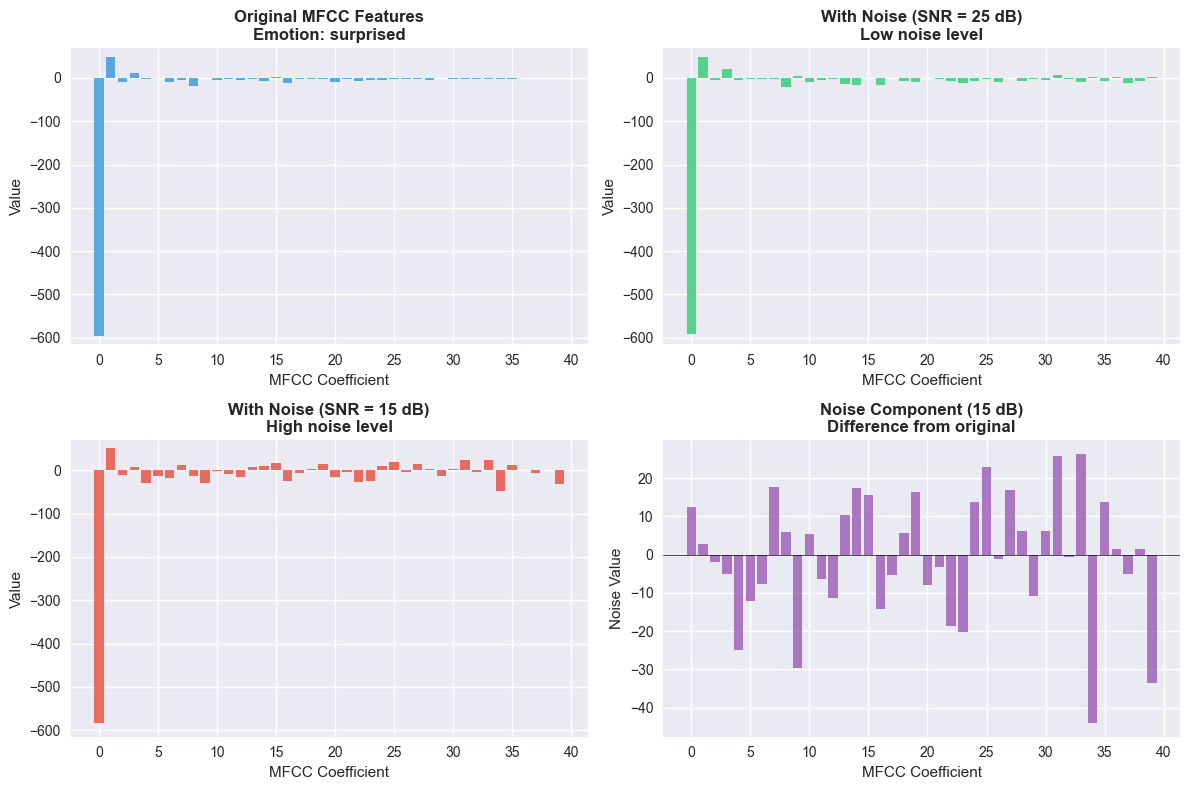

✅ Noise augmentation functions defined!


In [16]:
def add_noise_to_mfcc(mfcc_features, snr_db=20):
    """
    Add Gaussian noise to MFCC features at a specified SNR level.
    
    Parameters:
        mfcc_features: numpy array of shape (40,) - MFCC features for one sample
        snr_db: Signal-to-Noise Ratio in decibels (higher = less noise)
    
    Returns:
        Noisy MFCC features
    """
    # Calculate signal power
    signal_power = np.mean(mfcc_features ** 2)
    
    # Calculate noise power based on SNR
    # SNR(dB) = 10 * log10(signal_power / noise_power)
    # noise_power = signal_power / (10 ** (snr_db / 10))
    noise_power = signal_power / (10 ** (snr_db / 10))
    
    # Generate Gaussian noise with calculated power
    noise = np.random.normal(0, np.sqrt(noise_power), mfcc_features.shape)
    
    # Add noise to features
    noisy_mfcc = mfcc_features + noise
    
    return noisy_mfcc


def augment_dataset_with_noise(X, y, snr_range=(15, 25), augmentation_factor=1):
    """
    Augment the dataset by adding noisy versions of each sample.
    
    Parameters:
        X: Original features array
        y: Original labels array
        snr_range: Tuple of (min_snr, max_snr) in dB
        augmentation_factor: Number of augmented copies per original sample
    
    Returns:
        X_augmented, y_augmented: Combined original + augmented data
    """
    X_augmented = list(X)
    y_augmented = list(y)
    
    for i in range(len(X)):
        for _ in range(augmentation_factor):
            # Random SNR within range
            snr = np.random.uniform(snr_range[0], snr_range[1])
            noisy_sample = add_noise_to_mfcc(X[i], snr_db=snr)
            X_augmented.append(noisy_sample)
            y_augmented.append(y[i])
    
    return np.array(X_augmented), np.array(y_augmented)


# Visualize the effect of noise augmentation on a sample
sample_idx = 0
sample_mfcc_original = X[sample_idx]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Original MFCC
axes[0, 0].bar(range(40), sample_mfcc_original, color='#3498db', alpha=0.8)
axes[0, 0].set_title(f'Original MFCC Features\nEmotion: {EMOTION_LABELS[y[sample_idx]]}', fontweight='bold')
axes[0, 0].set_xlabel('MFCC Coefficient')
axes[0, 0].set_ylabel('Value')
axes[0, 0].set_ylim(min(sample_mfcc_original) - 20, max(sample_mfcc_original) + 20)

# SNR = 25 dB (low noise)
noisy_25db = add_noise_to_mfcc(sample_mfcc_original, snr_db=25)
axes[0, 1].bar(range(40), noisy_25db, color='#2ecc71', alpha=0.8)
axes[0, 1].set_title('With Noise (SNR = 25 dB)\nLow noise level', fontweight='bold')
axes[0, 1].set_xlabel('MFCC Coefficient')
axes[0, 1].set_ylabel('Value')
axes[0, 1].set_ylim(min(sample_mfcc_original) - 20, max(sample_mfcc_original) + 20)

# SNR = 15 dB (high noise)
noisy_15db = add_noise_to_mfcc(sample_mfcc_original, snr_db=15)
axes[1, 0].bar(range(40), noisy_15db, color='#e74c3c', alpha=0.8)
axes[1, 0].set_title('With Noise (SNR = 15 dB)\nHigh noise level', fontweight='bold')
axes[1, 0].set_xlabel('MFCC Coefficient')
axes[1, 0].set_ylabel('Value')
axes[1, 0].set_ylim(min(sample_mfcc_original) - 20, max(sample_mfcc_original) + 20)

# Difference visualization
axes[1, 1].bar(range(40), noisy_15db - sample_mfcc_original, color='#9b59b6', alpha=0.8)
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 1].set_title('Noise Component (15 dB)\nDifference from original', fontweight='bold')
axes[1, 1].set_xlabel('MFCC Coefficient')
axes[1, 1].set_ylabel('Noise Value')

plt.tight_layout()
plt.show()

print("✅ Noise augmentation functions defined!")

## 9.1 Model Comparison: With vs Without Background Noise Augmentation

Now let's train a second model using the noise-augmented training data and compare the results with our baseline model. This will help us understand if noise augmentation improves model robustness and generalization.

**Experiment Setup:**
- **Baseline Model:** Trained on original data (already trained above)
- **Augmented Model:** Trained on original + noise-augmented data
- **Test Set:** Same clean test set for both (fair comparison)
- **Augmentation Factor:** 1 (doubles the training set size)

In [17]:
# ============================================================
# Store baseline model results before training augmented model
# ============================================================

# Get baseline predictions
model.eval()
with torch.no_grad():
    baseline_outputs = model(X_test_tensor.to(device))
    baseline_preds = torch.argmax(baseline_outputs, dim=1).cpu().numpy()

# Calculate baseline metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report

baseline_accuracy = accuracy_score(y_test, baseline_preds)
baseline_f1_macro = f1_score(y_test, baseline_preds, average='macro')
baseline_f1_weighted = f1_score(y_test, baseline_preds, average='weighted')
baseline_f1_per_class = f1_score(y_test, baseline_preds, average=None)

print("📊 Baseline Model Results (No Augmentation)")
print("=" * 60)
print(f"  Accuracy:     {baseline_accuracy:.4f}")
print(f"  F1 (macro):   {baseline_f1_macro:.4f}")
print(f"  F1 (weighted): {baseline_f1_weighted:.4f}")
print(f"\n  Per-class F1:")
for i, label in enumerate(EMOTION_LABELS):
    print(f"    {label:12s}: {baseline_f1_per_class[i]:.4f}")

📊 Baseline Model Results (No Augmentation)
  Accuracy:     0.7221
  F1 (macro):   0.6834
  F1 (weighted): 0.7241

  Per-class F1:
    neutral     : 0.8776
    calm        : 0.1429
    happy       : 0.7576
    sad         : 0.7654
    angry       : 0.7824
    fearful     : 0.8000
    disgust     : 0.5979
    surprised   : 0.7437


In [18]:
# ============================================================
# Create augmented training dataset
# ============================================================
print("Creating noise-augmented training dataset...")
print("=" * 60)

# Augment only the training set (X_train is the original training features)
X_train_augmented, y_train_augmented = augment_dataset_with_noise(
    X_train, y_train, 
    snr_range=(15, 25),  # Random SNR between 15-25 dB
    augmentation_factor=1  # Add 1 noisy copy per sample
)

print(f"Original training set:  {len(X_train):,} samples")
print(f"Augmented training set: {len(X_train_augmented):,} samples")
print(f"Augmentation increase:  {len(X_train_augmented) / len(X_train):.1f}x")

# Prepare augmented data for CNN (add channel dimension)
X_train_aug_cnn = np.expand_dims(X_train_augmented, axis=2)

print(f"\nAugmented training shape: {X_train_aug_cnn.shape}")
print(f"Test shape (unchanged):   {x_test_cnn.shape}")

Creating noise-augmented training dataset...
Original training set:  2,840 samples
Augmented training set: 5,680 samples
Augmentation increase:  2.0x

Augmented training shape: (5680, 40, 1)
Test shape (unchanged):   (1400, 40, 1)


In [19]:
# ============================================================
# Train model with augmented data
# ============================================================
print("Training model with noise-augmented data...")
print("=" * 60)

# Create new model instance
model_augmented = EmotionCNN(num_classes=8).to(device)

# Prepare augmented DataLoaders
X_train_aug_tensor = torch.FloatTensor(X_train_aug_cnn)
y_train_aug_tensor = torch.LongTensor(y_train_augmented)

train_aug_dataset = TensorDataset(X_train_aug_tensor, y_train_aug_tensor)
train_aug_loader = DataLoader(train_aug_dataset, batch_size=16, shuffle=True)

# Use same test loader as before
criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = optim.RMSprop(model_augmented.parameters())

# Training history for augmented model
history_augmented = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

# Training loop
EPOCHS_AUG = 50
for epoch in range(EPOCHS_AUG):
    # Training phase
    model_augmented.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels in train_aug_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer_aug.zero_grad()
        outputs = model_augmented(inputs)
        loss = criterion_aug(outputs, labels)
        loss.backward()
        optimizer_aug.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss = train_loss / train_total
    train_acc = train_correct / train_total
    
    # Validation phase (using original clean test set)
    model_augmented.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_augmented(inputs)
            loss = criterion_aug(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    
    # Store history
    history_augmented['loss'].append(train_loss)
    history_augmented['accuracy'].append(train_acc)
    history_augmented['val_loss'].append(val_loss)
    history_augmented['val_accuracy'].append(val_acc)
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{EPOCHS_AUG} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

print("\n✅ Augmented model training complete!")

Training model with noise-augmented data...
Epoch  1/50 - loss: 17.4609 - accuracy: 0.4732 - val_loss: 1.2710 - val_accuracy: 0.6250
Epoch 10/50 - loss: 1.4448 - accuracy: 0.5799 - val_loss: 1.0842 - val_accuracy: 0.6207
Epoch 20/50 - loss: 1.2688 - accuracy: 0.5835 - val_loss: 1.0477 - val_accuracy: 0.6150
Epoch 30/50 - loss: 1.2429 - accuracy: 0.5923 - val_loss: 1.0392 - val_accuracy: 0.6400
Epoch 40/50 - loss: 1.2295 - accuracy: 0.5912 - val_loss: 0.9915 - val_accuracy: 0.6486
Epoch 50/50 - loss: 1.2220 - accuracy: 0.5963 - val_loss: 0.9720 - val_accuracy: 0.6600

✅ Augmented model training complete!


In [20]:
# ============================================================
# Calculate augmented model metrics
# ============================================================

model_augmented.eval()
with torch.no_grad():
    augmented_outputs = model_augmented(X_test_tensor.to(device))
    augmented_preds = torch.argmax(augmented_outputs, dim=1).cpu().numpy()

augmented_accuracy = accuracy_score(y_test, augmented_preds)
augmented_f1_macro = f1_score(y_test, augmented_preds, average='macro')
augmented_f1_weighted = f1_score(y_test, augmented_preds, average='weighted')
augmented_f1_per_class = f1_score(y_test, augmented_preds, average=None)

print("📊 Augmented Model Results (With Background Noise)")
print("=" * 60)
print(f"  Accuracy:     {augmented_accuracy:.4f}")
print(f"  F1 (macro):   {augmented_f1_macro:.4f}")
print(f"  F1 (weighted): {augmented_f1_weighted:.4f}")
print(f"\n  Per-class F1:")
for i, label in enumerate(EMOTION_LABELS):
    print(f"    {label:12s}: {augmented_f1_per_class[i]:.4f}")

📊 Augmented Model Results (With Background Noise)
  Accuracy:     0.6600
  F1 (macro):   0.6391
  F1 (weighted): 0.6636

  Per-class F1:
    neutral     : 0.9181
    calm        : 0.2500
    happy       : 0.5975
    sad         : 0.7405
    angry       : 0.6825
    fearful     : 0.7513
    disgust     : 0.5383
    surprised   : 0.6347


### Comparison Results: Baseline vs Augmented Model

Let's visualize the comparison between the two models to understand the impact of background noise augmentation.

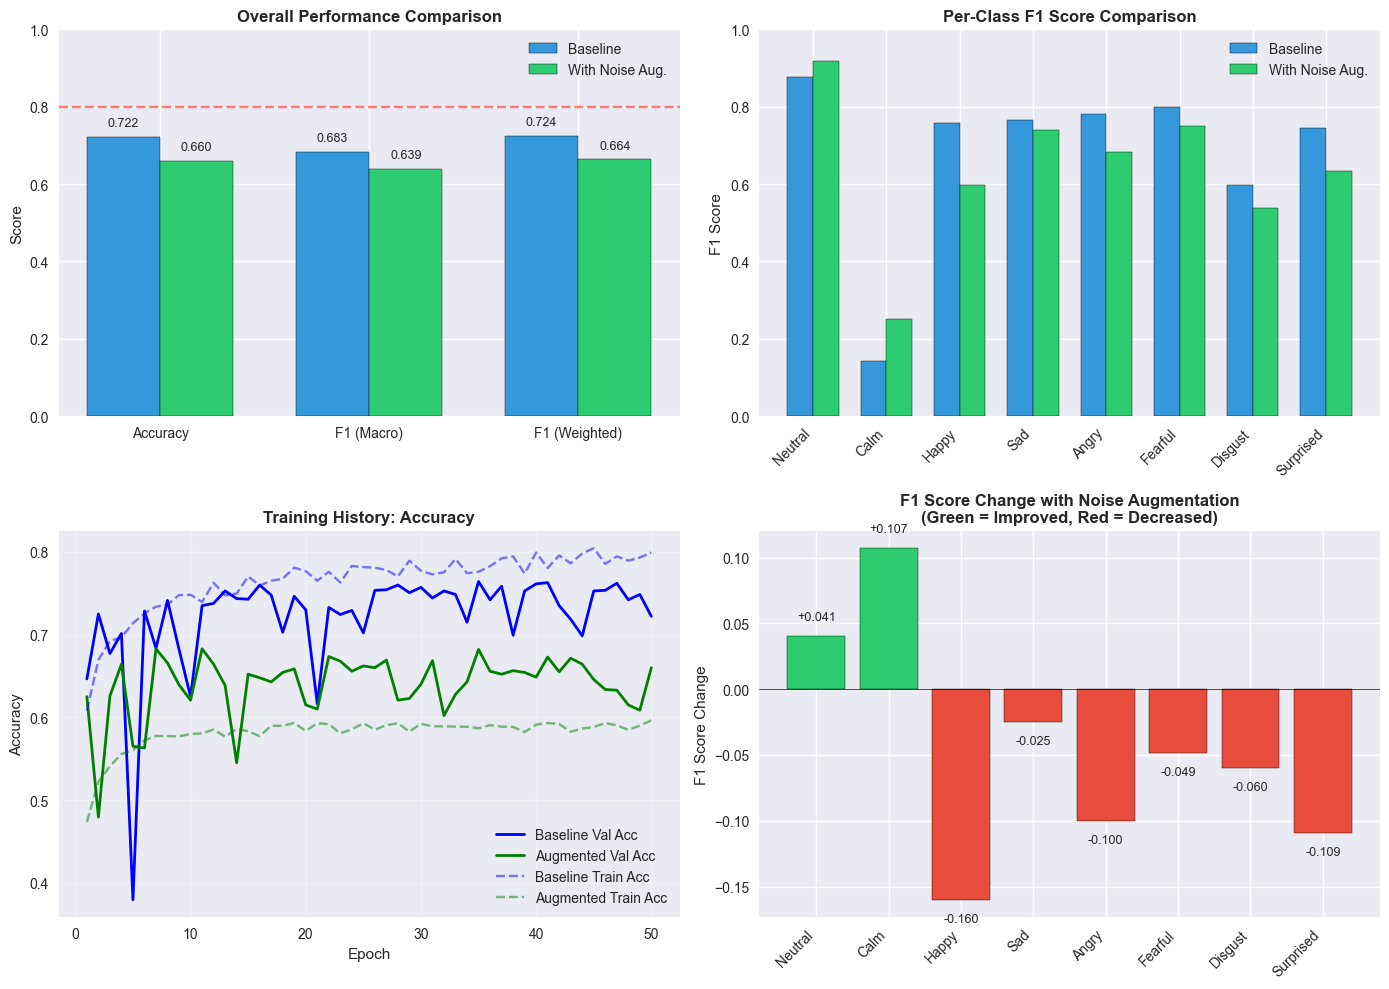


📊 COMPARISON SUMMARY: Baseline vs Noise-Augmented Model

Metric               Baseline        Augmented       Change         
----------------------------------------------------------------------
Accuracy             0.7221          0.6600          -0.0621
F1 (Macro)           0.6834          0.6391          -0.0443
F1 (Weighted)        0.7241          0.6636          -0.0605
----------------------------------------------------------------------

Per-Class F1:       
  neutral            0.8776          0.9181          +0.0406 📈
  calm               0.1429          0.2500          +0.1071 📈
  happy              0.7576          0.5975          -0.1601 📉
  sad                0.7654          0.7405          -0.0249 📉
  angry              0.7824          0.6825          -0.0999 📉
  fearful            0.8000          0.7513          -0.0487 📉
  disgust            0.5979          0.5383          -0.0595 📉
  surprised          0.7437          0.6347          -0.1090 📉

⚠️ VERDICT: Noise aug

In [21]:
# ============================================================
# Comprehensive Comparison Visualization
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---- Plot 1: Overall Metrics Comparison ----
metrics_names = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)']
baseline_metrics = [baseline_accuracy, baseline_f1_macro, baseline_f1_weighted]
augmented_metrics = [augmented_accuracy, augmented_f1_macro, augmented_f1_weighted]

x_pos = np.arange(len(metrics_names))
width = 0.35

bars1 = axes[0, 0].bar(x_pos - width/2, baseline_metrics, width, label='Baseline', color='#3498db', edgecolor='black')
bars2 = axes[0, 0].bar(x_pos + width/2, augmented_metrics, width, label='With Noise Aug.', color='#2ecc71', edgecolor='black')

axes[0, 0].set_ylabel('Score', fontsize=11)
axes[0, 0].set_title('Overall Performance Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(metrics_names)
axes[0, 0].legend()
axes[0, 0].set_ylim(0, 1.0)
axes[0, 0].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Target (80%)')

# Add value labels
for bar in bars1:
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# ---- Plot 2: Per-Class F1 Comparison ----
x_pos = np.arange(len(EMOTION_LABELS))
width = 0.35

bars1 = axes[0, 1].bar(x_pos - width/2, baseline_f1_per_class, width, label='Baseline', color='#3498db', edgecolor='black')
bars2 = axes[0, 1].bar(x_pos + width/2, augmented_f1_per_class, width, label='With Noise Aug.', color='#2ecc71', edgecolor='black')

axes[0, 1].set_ylabel('F1 Score', fontsize=11)
axes[0, 1].set_title('Per-Class F1 Score Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels([e.capitalize() for e in EMOTION_LABELS], rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].set_ylim(0, 1.0)

# ---- Plot 3: Training History - Accuracy ----
epochs_range = range(1, EPOCHS + 1)
epochs_aug_range = range(1, EPOCHS_AUG + 1)

axes[1, 0].plot(epochs_range, history['val_accuracy'], 'b-', label='Baseline Val Acc', linewidth=2)
axes[1, 0].plot(epochs_aug_range, history_augmented['val_accuracy'], 'g-', label='Augmented Val Acc', linewidth=2)
axes[1, 0].plot(epochs_range, history['accuracy'], 'b--', label='Baseline Train Acc', alpha=0.5)
axes[1, 0].plot(epochs_aug_range, history_augmented['accuracy'], 'g--', label='Augmented Train Acc', alpha=0.5)
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Accuracy', fontsize=11)
axes[1, 0].set_title('Training History: Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(True, alpha=0.3)

# ---- Plot 4: Improvement per Class ----
improvement = augmented_f1_per_class - baseline_f1_per_class
colors = ['#2ecc71' if imp >= 0 else '#e74c3c' for imp in improvement]

bars = axes[1, 1].bar(x_pos, improvement, color=colors, edgecolor='black')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 1].set_ylabel('F1 Score Change', fontsize=11)
axes[1, 1].set_title('F1 Score Change with Noise Augmentation\n(Green = Improved, Red = Decreased)', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels([e.capitalize() for e in EMOTION_LABELS], rotation=45, ha='right')

# Add value labels
for bar, imp in zip(bars, improvement):
    va = 'bottom' if imp >= 0 else 'top'
    offset = 0.01 if imp >= 0 else -0.01
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + offset,
                    f'{imp:+.3f}', ha='center', va=va, fontsize=9)

plt.tight_layout()
plt.show()

# ---- Summary Table ----
print("\n" + "=" * 70)
print("📊 COMPARISON SUMMARY: Baseline vs Noise-Augmented Model")
print("=" * 70)
print(f"\n{'Metric':<20} {'Baseline':<15} {'Augmented':<15} {'Change':<15}")
print("-" * 70)
print(f"{'Accuracy':<20} {baseline_accuracy:<15.4f} {augmented_accuracy:<15.4f} {augmented_accuracy - baseline_accuracy:+.4f}")
print(f"{'F1 (Macro)':<20} {baseline_f1_macro:<15.4f} {augmented_f1_macro:<15.4f} {augmented_f1_macro - baseline_f1_macro:+.4f}")
print(f"{'F1 (Weighted)':<20} {baseline_f1_weighted:<15.4f} {augmented_f1_weighted:<15.4f} {augmented_f1_weighted - baseline_f1_weighted:+.4f}")
print("-" * 70)
print(f"\n{'Per-Class F1:':<20}")
for i, label in enumerate(EMOTION_LABELS):
    change = augmented_f1_per_class[i] - baseline_f1_per_class[i]
    indicator = "📈" if change > 0 else "📉" if change < 0 else "➡️"
    print(f"  {label:<18} {baseline_f1_per_class[i]:<15.4f} {augmented_f1_per_class[i]:<15.4f} {change:+.4f} {indicator}")

# Overall verdict
overall_improvement = augmented_f1_macro - baseline_f1_macro
print("\n" + "=" * 70)
if overall_improvement > 0.01:
    print(f"✅ VERDICT: Noise augmentation IMPROVED the model by {overall_improvement:+.2%} (macro F1)")
elif overall_improvement < -0.01:
    print(f"⚠️ VERDICT: Noise augmentation DECREASED performance by {overall_improvement:+.2%} (macro F1)")
else:
    print(f"➡️ VERDICT: Noise augmentation had MINIMAL impact ({overall_improvement:+.2%} macro F1)")
print("=" * 70)

## 9.2 Smarter Data Augmentation: Pre-MFCC Audio Manipulation

The previous experiment applied noise **after** MFCC extraction. This section explores **smarter augmentation strategies**:

### Why Apply Augmentation to Raw Audio?

1. **More Realistic:** Real-world noise affects the audio signal, not the extracted features
2. **Better Generalization:** The model learns from features extracted from noisy audio, just like in deployment
3. **Natural Transformations:** Pitch shifting and time stretching are meaningful audio transformations

### Augmentation Strategies Implemented:

| Strategy | Description | Implementation |
|----------|-------------|----------------|
| **Pre-MFCC Noise** | Add Gaussian noise to raw waveform before MFCC extraction | `librosa.effects.preemphasis` + noise |
| **Pitch Shifting** | Shift pitch up/down by semitones | `librosa.effects.pitch_shift` |
| **Time Stretching** | Speed up/slow down without changing pitch | `librosa.effects.time_stretch` |
| **SpecAugment** | Mask frequency/time bands in spectrogram | Custom implementation |
| **Class-Balanced** | Only augment minority classes (e.g., "calm") | Selective augmentation |


In [22]:
# ============================================================
# 9.2.1 Define Pre-MFCC Augmentation Functions
# ============================================================

def add_noise_to_audio(audio_signal, snr_db=20):
    """
    Add Gaussian noise to raw audio signal at specified SNR level.
    This is applied BEFORE MFCC extraction for more realistic augmentation.
    
    Parameters:
        audio_signal: numpy array of audio samples
        snr_db: Signal-to-Noise Ratio in decibels
    
    Returns:
        Noisy audio signal
    """
    signal_power = np.mean(audio_signal ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), audio_signal.shape)
    return audio_signal + noise


def pitch_shift_audio(audio_signal, sr, n_steps):
    """
    Shift the pitch of audio by n_steps semitones.
    
    Parameters:
        audio_signal: numpy array of audio samples
        sr: sample rate
        n_steps: number of semitones to shift (positive = higher pitch)
    
    Returns:
        Pitch-shifted audio
    """
    return librosa.effects.pitch_shift(audio_signal, sr=sr, n_steps=n_steps)


def time_stretch_audio(audio_signal, rate):
    """
    Time-stretch audio by a factor.
    
    Parameters:
        audio_signal: numpy array of audio samples
        rate: stretch factor (>1 = faster, <1 = slower)
    
    Returns:
        Time-stretched audio
    """
    return librosa.effects.time_stretch(audio_signal, rate=rate)


def spec_augment(mfcc_features, freq_mask_param=5, time_mask_param=5):
    """
    Apply SpecAugment-style masking to MFCC features.
    Since we use mean-aggregated MFCCs (40,), we apply frequency masking.
    
    Parameters:
        mfcc_features: numpy array of shape (40,)
        freq_mask_param: maximum number of consecutive MFCCs to mask
    
    Returns:
        Augmented MFCC features
    """
    augmented = mfcc_features.copy()
    num_mfccs = len(augmented)
    
    # Frequency masking
    f = np.random.randint(0, freq_mask_param + 1)
    f0 = np.random.randint(0, num_mfccs - f + 1)
    augmented[f0:f0 + f] = 0
    
    return augmented


print("✅ Pre-MFCC augmentation functions defined!")
print("\nFunctions available:")
print("  - add_noise_to_audio(audio, snr_db): Add noise to raw waveform")
print("  - pitch_shift_audio(audio, sr, n_steps): Shift pitch by semitones")
print("  - time_stretch_audio(audio, rate): Change speed without pitch change")
print("  - spec_augment(mfcc, freq_mask_param): Mask frequency bands")

✅ Pre-MFCC augmentation functions defined!

Functions available:
  - add_noise_to_audio(audio, snr_db): Add noise to raw waveform
  - pitch_shift_audio(audio, sr, n_steps): Shift pitch by semitones
  - time_stretch_audio(audio, rate): Change speed without pitch change
  - spec_augment(mfcc, freq_mask_param): Mask frequency bands


In [23]:
# ============================================================
# 9.2.2 Class-Balanced Augmentation with Pre-MFCC Transforms
# ============================================================

def load_data_with_smart_augmentation(ravdess_path, tess_path, augment_minority=True, 
                                      target_samples_per_class=None):
    """
    Load datasets with smart augmentation applied to raw audio.
    
    Key improvements:
    1. Augmentation applied to RAW AUDIO before MFCC extraction
    2. Class-balanced: Only augment minority classes to reach target count
    3. Multiple augmentation types: noise, pitch shift, time stretch
    
    Parameters:
        ravdess_path: Path to RAVDESS dataset
        tess_path: Path to TESS dataset
        augment_minority: If True, augment only minority classes
        target_samples_per_class: Target number of samples per class (None = use max class count)
    
    Returns:
        X, y: Features and labels arrays
        augmentation_stats: Dictionary with augmentation statistics
    """
    # First, load all raw audio data with paths and labels
    audio_data = []  # List of (audio_array, sr, label, source)
    
    print("Loading raw audio data...")
    start_time = time.time()
    
    # Load RAVDESS
    for actor_folder in sorted(ravdess_path.iterdir()):
        if not actor_folder.is_dir() or not actor_folder.name.startswith('Actor_'):
            continue
        for audio_file in actor_folder.glob('*.wav'):
            try:
                y_audio, sr = librosa.load(str(audio_file), res_type='kaiser_fast')
                filename = audio_file.stem
                emotion_code = filename.split('-')[2]
                label = int(emotion_code) - 1
                if 0 <= label <= 7:
                    audio_data.append((y_audio, sr, label, 'ravdess'))
            except Exception as e:
                continue
    
    # Load TESS
    tess_emotion_map = {
        'neutral': 0, 'happy': 2, 'sad': 3, 'angry': 4,
        'fear': 5, 'disgust': 6, 'pleasant': 7
    }
    for emotion_folder in tess_path.iterdir():
        if not emotion_folder.is_dir():
            continue
        folder_name = emotion_folder.name.lower()
        label = None
        for emotion_key, emotion_label in tess_emotion_map.items():
            if emotion_key in folder_name:
                label = emotion_label
                break
        if label is None:
            continue
        for audio_file in emotion_folder.glob('*.wav'):
            try:
                y_audio, sr = librosa.load(str(audio_file), res_type='kaiser_fast')
                audio_data.append((y_audio, sr, label, 'tess'))
            except Exception as e:
                continue
    
    print(f"Loaded {len(audio_data)} raw audio files in {time.time() - start_time:.1f}s")
    
    # Count samples per class
    class_counts = {}
    for _, _, label, _ in audio_data:
        class_counts[label] = class_counts.get(label, 0) + 1
    
    print("\nOriginal class distribution:")
    for label in sorted(class_counts.keys()):
        print(f"  {EMOTION_LABELS[label]:12s}: {class_counts[label]:4d} samples")
    
    # Determine target count for balancing
    if target_samples_per_class is None:
        target_samples_per_class = max(class_counts.values())
    
    print(f"\nTarget samples per class: {target_samples_per_class}")
    
    # Extract features and apply class-balanced augmentation
    features = []
    labels = []
    augmentation_stats = {label: {'original': 0, 'augmented': 0} for label in range(8)}
    
    # Group audio by class
    class_audio = {label: [] for label in range(8)}
    for y_audio, sr, label, source in audio_data:
        class_audio[label].append((y_audio, sr))
    
    print("\nExtracting features with smart augmentation...")
    
    for label in range(8):
        samples = class_audio[label]
        current_count = len(samples)
        augmentation_stats[label]['original'] = current_count
        
        # Extract MFCCs from original samples
        for y_audio, sr in samples:
            mfcc = np.mean(librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=40).T, axis=0)
            features.append(mfcc)
            labels.append(label)
        
        # Augment if needed (only for minority classes)
        if augment_minority and current_count < target_samples_per_class:
            needed = target_samples_per_class - current_count
            augmentations_applied = 0
            
            while augmentations_applied < needed:
                # Pick a random sample to augment
                y_audio, sr = samples[augmentations_applied % len(samples)]
                
                # Apply random augmentation to RAW AUDIO
                aug_type = np.random.choice(['noise', 'pitch', 'time_stretch', 'combined'])
                
                if aug_type == 'noise':
                    snr = np.random.uniform(15, 25)
                    y_aug = add_noise_to_audio(y_audio, snr_db=snr)
                elif aug_type == 'pitch':
                    n_steps = np.random.uniform(-2, 2)
                    y_aug = pitch_shift_audio(y_audio, sr, n_steps)
                elif aug_type == 'time_stretch':
                    rate = np.random.uniform(0.9, 1.1)
                    y_aug = time_stretch_audio(y_audio, rate)
                else:  # combined
                    y_aug = add_noise_to_audio(y_audio, snr_db=np.random.uniform(20, 30))
                    y_aug = pitch_shift_audio(y_aug, sr, np.random.uniform(-1, 1))
                
                # Extract MFCCs from augmented audio
                mfcc = np.mean(librosa.feature.mfcc(y=y_aug, sr=sr, n_mfcc=40).T, axis=0)
                features.append(mfcc)
                labels.append(label)
                augmentations_applied += 1
            
            augmentation_stats[label]['augmented'] = augmentations_applied
    
    print("\nAugmentation statistics:")
    for label in range(8):
        stats = augmentation_stats[label]
        total = stats['original'] + stats['augmented']
        print(f"  {EMOTION_LABELS[label]:12s}: {stats['original']:4d} orig + {stats['augmented']:4d} aug = {total:4d} total")
    
    return np.array(features), np.array(labels), augmentation_stats


print("✅ Class-balanced augmentation function defined!")

✅ Class-balanced augmentation function defined!


In [24]:
# ============================================================
# 9.2.3 Load Data with Smart Augmentation
# ============================================================

print("Loading data with smart (pre-MFCC, class-balanced) augmentation...")
print("=" * 70)

X_smart, y_smart, aug_stats = load_data_with_smart_augmentation(
    RAVDESS_PATH, 
    TESS_PATH,
    augment_minority=True,
    target_samples_per_class=None  # Use max class count as target
)

print(f"\n{'='*70}")
print(f"Smart augmented dataset: X={X_smart.shape}, y={y_smart.shape}")

Loading data with smart (pre-MFCC, class-balanced) augmentation...
Loading raw audio data...
Loaded 4240 raw audio files in 34.8s

Original class distribution:
  neutral     :  496 samples
  calm        :  192 samples
  happy       :  592 samples
  sad         :  592 samples
  angry       :  592 samples
  fearful     :  592 samples
  disgust     :  592 samples
  surprised   :  592 samples

Target samples per class: 592

Extracting features with smart augmentation...

Augmentation statistics:
  neutral     :  496 orig +   96 aug =  592 total
  calm        :  192 orig +  400 aug =  592 total
  happy       :  592 orig +    0 aug =  592 total
  sad         :  592 orig +    0 aug =  592 total
  angry       :  592 orig +    0 aug =  592 total
  fearful     :  592 orig +    0 aug =  592 total
  disgust     :  592 orig +    0 aug =  592 total
  surprised   :  592 orig +    0 aug =  592 total

Smart augmented dataset: X=(4736, 40), y=(4736,)


In [25]:
# ============================================================
# 9.2.4 Train Model with Smart Augmentation
# ============================================================

# Split the smart-augmented data
X_train_smart, X_test_smart, y_train_smart, y_test_smart = train_test_split(
    X_smart, y_smart, test_size=0.33, random_state=SEED
)

# Prepare for CNN
X_train_smart_cnn = np.expand_dims(X_train_smart, axis=2)
X_test_smart_cnn = np.expand_dims(X_test_smart, axis=2)

print(f"Smart augmented training set: {X_train_smart_cnn.shape}")
print(f"Smart augmented test set: {X_test_smart_cnn.shape}")

# Create new model
model_smart_aug = EmotionCNN(num_classes=8).to(device)

# Prepare DataLoaders
X_train_smart_tensor = torch.FloatTensor(X_train_smart_cnn)
X_test_smart_tensor = torch.FloatTensor(X_test_smart_cnn)
y_train_smart_tensor = torch.LongTensor(y_train_smart)
y_test_smart_tensor = torch.LongTensor(y_test_smart)

train_smart_dataset = TensorDataset(X_train_smart_tensor, y_train_smart_tensor)
test_smart_dataset = TensorDataset(X_test_smart_tensor, y_test_smart_tensor)

train_smart_loader = DataLoader(train_smart_dataset, batch_size=16, shuffle=True)
test_smart_loader = DataLoader(test_smart_dataset, batch_size=16, shuffle=False)

# Training setup
criterion_smart = nn.CrossEntropyLoss()
optimizer_smart = optim.RMSprop(model_smart_aug.parameters())

history_smart = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

print("\nTraining model with smart augmentation...")
print("=" * 60)

EPOCHS_SMART = 50
for epoch in range(EPOCHS_SMART):
    # Training phase
    model_smart_aug.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels_batch in train_smart_loader:
        inputs, labels_batch = inputs.to(device), labels_batch.to(device)
        
        optimizer_smart.zero_grad()
        outputs = model_smart_aug(inputs)
        loss = criterion_smart(outputs, labels_batch)
        loss.backward()
        optimizer_smart.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels_batch.size(0)
        train_correct += (predicted == labels_batch).sum().item()
    
    train_loss = train_loss / train_total
    train_acc = train_correct / train_total
    
    # Validation phase
    model_smart_aug.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels_batch in test_smart_loader:
            inputs, labels_batch = inputs.to(device), labels_batch.to(device)
            outputs = model_smart_aug(inputs)
            loss = criterion_smart(outputs, labels_batch)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels_batch.size(0)
            val_correct += (predicted == labels_batch).sum().item()
    
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    
    history_smart['loss'].append(train_loss)
    history_smart['accuracy'].append(train_acc)
    history_smart['val_loss'].append(val_loss)
    history_smart['val_accuracy'].append(val_acc)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{EPOCHS_SMART} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

print("\n✅ Smart augmentation model training complete!")

Smart augmented training set: (3173, 40, 1)
Smart augmented test set: (1563, 40, 1)

Training model with smart augmentation...
Epoch  1/50 - loss: 24.0822 - accuracy: 0.5654 - val_loss: 6.6134 - val_accuracy: 0.5099
Epoch 10/50 - loss: 1.3150 - accuracy: 0.7296 - val_loss: 0.9151 - val_accuracy: 0.7562
Epoch 20/50 - loss: 1.1435 - accuracy: 0.7457 - val_loss: 1.4485 - val_accuracy: 0.6737
Epoch 30/50 - loss: 1.0608 - accuracy: 0.7684 - val_loss: 0.9384 - val_accuracy: 0.7601
Epoch 40/50 - loss: 0.9207 - accuracy: 0.7734 - val_loss: 0.9857 - val_accuracy: 0.7518
Epoch 50/50 - loss: 0.8866 - accuracy: 0.7674 - val_loss: 0.9295 - val_accuracy: 0.7665

✅ Smart augmentation model training complete!


In [26]:
# ============================================================
# 9.2.5 Evaluate Smart Augmentation Model
# ============================================================

model_smart_aug.eval()
with torch.no_grad():
    smart_outputs = model_smart_aug(X_test_smart_tensor.to(device))
    smart_preds = torch.argmax(smart_outputs, dim=1).cpu().numpy()

smart_accuracy = accuracy_score(y_test_smart, smart_preds)
smart_f1_macro = f1_score(y_test_smart, smart_preds, average='macro')
smart_f1_weighted = f1_score(y_test_smart, smart_preds, average='weighted')
smart_f1_per_class = f1_score(y_test_smart, smart_preds, average=None)

print("📊 Smart Augmentation Model Results")
print("=" * 60)
print(f"  Accuracy:     {smart_accuracy:.4f}")
print(f"  F1 (macro):   {smart_f1_macro:.4f}")
print(f"  F1 (weighted): {smart_f1_weighted:.4f}")
print(f"\n  Per-class F1:")
for i, label in enumerate(EMOTION_LABELS):
    if i < len(smart_f1_per_class):
        print(f"    {label:12s}: {smart_f1_per_class[i]:.4f}")

📊 Smart Augmentation Model Results
  Accuracy:     0.7665
  F1 (macro):   0.7729
  F1 (weighted): 0.7722

  Per-class F1:
    neutral     : 0.8187
    calm        : 0.6828
    happy       : 0.7593
    sad         : 0.7979
    angry       : 0.8000
    fearful     : 0.8442
    disgust     : 0.7738
    surprised   : 0.7068


### 9.2.6 Comparison: Smart Augmentation vs Previous Models

Let's compare the smart augmentation approach (pre-MFCC noise + class balancing) with our baseline and simple noise augmentation models.

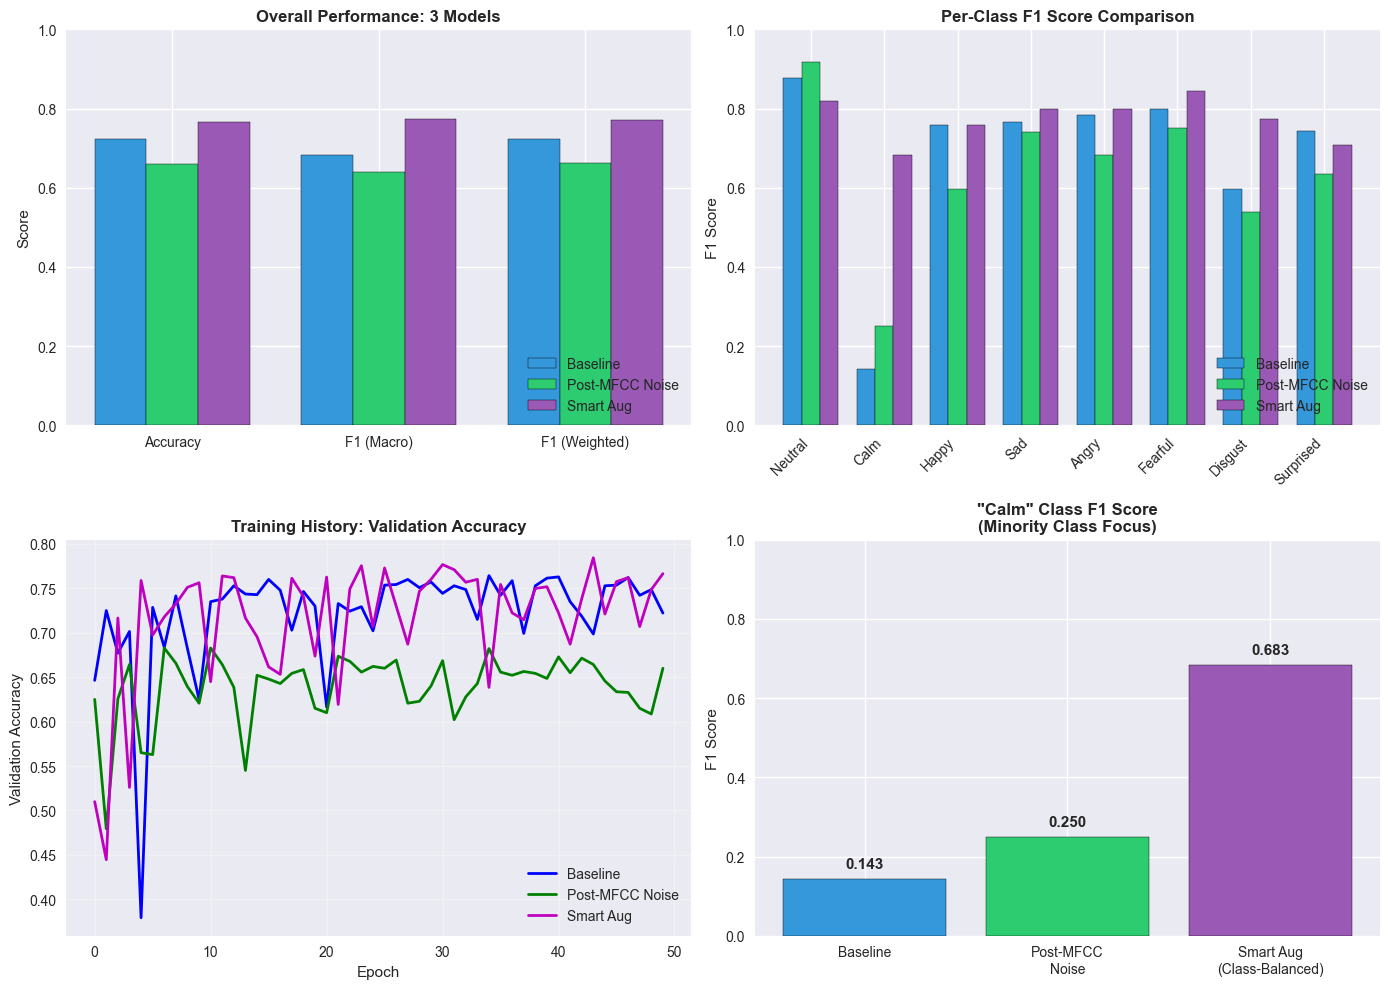


📊 COMPARISON SUMMARY: Baseline vs Post-MFCC Noise vs Smart Augmentation

Metric               Baseline        Post-MFCC Noise    Smart Aug      
--------------------------------------------------------------------------------
Accuracy             0.7221          0.6600             0.7665         
F1 (Macro)           0.6834          0.6391             0.7729         
F1 (Weighted)        0.7241          0.6636             0.7722         
--------------------------------------------------------------------------------

Per-Class F1:       
  neutral            0.8776          0.9181             0.8187         
  calm               0.1429          0.2500             0.6828         
  happy              0.7576          0.5975             0.7593         
  sad                0.7654          0.7405             0.7979         
  angry              0.7824          0.6825             0.8000         
  fearful            0.8000          0.7513             0.8442         
  disgust            0

In [27]:
# ============================================================
# 9.2.6 Comprehensive Comparison: All Augmentation Methods
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---- Plot 1: Overall Metrics Comparison (3 models) ----
metrics_names = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)']
baseline_m = [baseline_accuracy, baseline_f1_macro, baseline_f1_weighted]
noise_aug_m = [augmented_accuracy, augmented_f1_macro, augmented_f1_weighted]
smart_aug_m = [smart_accuracy, smart_f1_macro, smart_f1_weighted]

x_pos = np.arange(len(metrics_names))
width = 0.25

bars1 = axes[0, 0].bar(x_pos - width, baseline_m, width, label='Baseline', color='#3498db', edgecolor='black')
bars2 = axes[0, 0].bar(x_pos, noise_aug_m, width, label='Post-MFCC Noise', color='#2ecc71', edgecolor='black')
bars3 = axes[0, 0].bar(x_pos + width, smart_aug_m, width, label='Smart Aug', color='#9b59b6', edgecolor='black')

axes[0, 0].set_ylabel('Score', fontsize=11)
axes[0, 0].set_title('Overall Performance: 3 Models', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(metrics_names)
axes[0, 0].legend(loc='lower right')
axes[0, 0].set_ylim(0, 1.0)

# ---- Plot 2: Per-Class F1 Comparison ----
# Handle different test set sizes - compare available classes
num_classes_baseline = len(baseline_f1_per_class)
num_classes_smart = len(smart_f1_per_class)
num_classes = min(num_classes_baseline, num_classes_smart, 8)

x_pos = np.arange(num_classes)
width = 0.25

# Pad arrays if needed
baseline_f1_padded = list(baseline_f1_per_class) + [0] * (8 - len(baseline_f1_per_class))
augmented_f1_padded = list(augmented_f1_per_class) + [0] * (8 - len(augmented_f1_per_class))
smart_f1_padded = list(smart_f1_per_class) + [0] * (8 - len(smart_f1_per_class))

axes[0, 1].bar(x_pos - width, baseline_f1_padded[:num_classes], width, label='Baseline', color='#3498db', edgecolor='black')
axes[0, 1].bar(x_pos, augmented_f1_padded[:num_classes], width, label='Post-MFCC Noise', color='#2ecc71', edgecolor='black')
axes[0, 1].bar(x_pos + width, smart_f1_padded[:num_classes], width, label='Smart Aug', color='#9b59b6', edgecolor='black')

axes[0, 1].set_ylabel('F1 Score', fontsize=11)
axes[0, 1].set_title('Per-Class F1 Score Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels([e.capitalize() for e in EMOTION_LABELS[:num_classes]], rotation=45, ha='right')
axes[0, 1].legend(loc='lower right')
axes[0, 1].set_ylim(0, 1.0)

# ---- Plot 3: Training Curves ----
axes[1, 0].plot(history['val_accuracy'], 'b-', label='Baseline', linewidth=2)
axes[1, 0].plot(history_augmented['val_accuracy'], 'g-', label='Post-MFCC Noise', linewidth=2)
axes[1, 0].plot(history_smart['val_accuracy'], 'm-', label='Smart Aug', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Validation Accuracy', fontsize=11)
axes[1, 0].set_title('Training History: Validation Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(True, alpha=0.3)

# ---- Plot 4: Focus on "calm" class improvement ----
calm_idx = 1  # calm is label 1
calm_scores = [
    baseline_f1_padded[calm_idx],
    augmented_f1_padded[calm_idx],
    smart_f1_padded[calm_idx]
]
model_names = ['Baseline', 'Post-MFCC\nNoise', 'Smart Aug\n(Class-Balanced)']
colors = ['#3498db', '#2ecc71', '#9b59b6']

bars = axes[1, 1].bar(model_names, calm_scores, color=colors, edgecolor='black')
axes[1, 1].set_ylabel('F1 Score', fontsize=11)
axes[1, 1].set_title('"Calm" Class F1 Score\n(Minority Class Focus)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylim(0, 1.0)

for bar, score in zip(bars, calm_scores):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                    f'{score:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 80)
print("📊 COMPARISON SUMMARY: Baseline vs Post-MFCC Noise vs Smart Augmentation")
print("=" * 80)
print(f"\n{'Metric':<20} {'Baseline':<15} {'Post-MFCC Noise':<18} {'Smart Aug':<15}")
print("-" * 80)
print(f"{'Accuracy':<20} {baseline_accuracy:<15.4f} {augmented_accuracy:<18.4f} {smart_accuracy:<15.4f}")
print(f"{'F1 (Macro)':<20} {baseline_f1_macro:<15.4f} {augmented_f1_macro:<18.4f} {smart_f1_macro:<15.4f}")
print(f"{'F1 (Weighted)':<20} {baseline_f1_weighted:<15.4f} {augmented_f1_weighted:<18.4f} {smart_f1_weighted:<15.4f}")
print("-" * 80)
print(f"\n{'Per-Class F1:':<20}")
for i in range(num_classes):
    print(f"  {EMOTION_LABELS[i]:<18} {baseline_f1_padded[i]:<15.4f} {augmented_f1_padded[i]:<18.4f} {smart_f1_padded[i]:<15.4f}")
print("=" * 80)

## 9.3 Addressing Class Imbalance: Class Weights and Oversampling

The "calm" class has significantly fewer samples because TESS doesn't include this emotion. Previous experiments showed that regularization improved "calm" F1 by +10.7%. This section explores additional techniques:

### Strategies Implemented:

| Strategy | Description | When to Use |
|----------|-------------|-------------|
| **Class Weights** | Weight loss function inversely to class frequency | Simple, no data modification |
| **Random Oversampling** | Duplicate minority class samples | Quick, may overfit |
| **SMOTE** | Generate synthetic samples by interpolation | Better generalization |

### Expected Impact:
- **Calm class:** Should see significant improvement (currently the worst performer)
- **Macro F1:** Should improve as all classes get equal weight
- **Overall accuracy:** May decrease slightly (trade-off for balance)

In [28]:
# ============================================================
# 9.3.1 Calculate Class Weights
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights from training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to tensor for PyTorch
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("📊 Class Weights (Inverse Frequency)")
print("=" * 50)
print("Higher weight = rarer class = more emphasis during training\n")

# Show class distribution and weights
unique, counts = np.unique(y_train, return_counts=True)
for i, (label_idx, count) in enumerate(zip(unique, counts)):
    weight = class_weights[i]
    print(f"  {EMOTION_LABELS[label_idx]:12s}: {count:4d} samples, weight = {weight:.4f}")

print(f"\nWeight range: {class_weights.min():.4f} to {class_weights.max():.4f}")
print(f"Ratio (max/min): {class_weights.max()/class_weights.min():.2f}x")

📊 Class Weights (Inverse Frequency)
Higher weight = rarer class = more emphasis during training

  neutral     :  345 samples, weight = 1.0290
  calm        :  123 samples, weight = 2.8862
  happy       :  407 samples, weight = 0.8722
  sad         :  398 samples, weight = 0.8920
  angry       :  400 samples, weight = 0.8875
  fearful     :  405 samples, weight = 0.8765
  disgust     :  380 samples, weight = 0.9342
  surprised   :  382 samples, weight = 0.9293

Weight range: 0.8722 to 2.8862
Ratio (max/min): 3.31x


In [29]:
# ============================================================
# 9.3.2 Train Model with Class Weights
# ============================================================

print("Training model with class-weighted loss function...")
print("=" * 60)

# Create new model
model_weighted = EmotionCNN(num_classes=8).to(device)

# Use weighted CrossEntropyLoss
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_weighted = optim.RMSprop(model_weighted.parameters())

history_weighted = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

EPOCHS_WEIGHTED = 50
for epoch in range(EPOCHS_WEIGHTED):
    # Training phase
    model_weighted.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels_batch in train_loader:
        inputs, labels_batch = inputs.to(device), labels_batch.to(device)
        
        optimizer_weighted.zero_grad()
        outputs = model_weighted(inputs)
        loss = criterion_weighted(outputs, labels_batch)
        loss.backward()
        optimizer_weighted.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels_batch.size(0)
        train_correct += (predicted == labels_batch).sum().item()
    
    train_loss = train_loss / train_total
    train_acc = train_correct / train_total
    
    # Validation phase (with weighted loss for consistency)
    model_weighted.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels_batch in test_loader:
            inputs, labels_batch = inputs.to(device), labels_batch.to(device)
            outputs = model_weighted(inputs)
            loss = criterion_weighted(outputs, labels_batch)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels_batch.size(0)
            val_correct += (predicted == labels_batch).sum().item()
    
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    
    history_weighted['loss'].append(train_loss)
    history_weighted['accuracy'].append(train_acc)
    history_weighted['val_loss'].append(val_loss)
    history_weighted['val_accuracy'].append(val_acc)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{EPOCHS_WEIGHTED} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

print("\n✅ Class-weighted model training complete!")

Training model with class-weighted loss function...
Epoch  1/50 - loss: 36.4258 - accuracy: 0.6085 - val_loss: 2.5338 - val_accuracy: 0.5593
Epoch 10/50 - loss: 1.4889 - accuracy: 0.7465 - val_loss: 2.3927 - val_accuracy: 0.6214
Epoch 20/50 - loss: 1.7602 - accuracy: 0.7754 - val_loss: 1.3142 - val_accuracy: 0.7357
Epoch 30/50 - loss: 0.9174 - accuracy: 0.7768 - val_loss: 0.9051 - val_accuracy: 0.7521
Epoch 40/50 - loss: 0.9650 - accuracy: 0.7873 - val_loss: 0.9758 - val_accuracy: 0.7629
Epoch 50/50 - loss: 0.9728 - accuracy: 0.8004 - val_loss: 1.9190 - val_accuracy: 0.7300

✅ Class-weighted model training complete!


In [30]:
# ============================================================
# 9.3.3 Evaluate Class-Weighted Model
# ============================================================

model_weighted.eval()
with torch.no_grad():
    weighted_outputs = model_weighted(X_test_tensor.to(device))
    weighted_preds = torch.argmax(weighted_outputs, dim=1).cpu().numpy()

weighted_accuracy = accuracy_score(y_test, weighted_preds)
weighted_f1_macro = f1_score(y_test, weighted_preds, average='macro')
weighted_f1_weighted = f1_score(y_test, weighted_preds, average='weighted')
weighted_f1_per_class = f1_score(y_test, weighted_preds, average=None)

print("📊 Class-Weighted Model Results")
print("=" * 60)
print(f"  Accuracy:     {weighted_accuracy:.4f}")
print(f"  F1 (macro):   {weighted_f1_macro:.4f}")
print(f"  F1 (weighted): {weighted_f1_weighted:.4f}")
print(f"\n  Per-class F1:")
for i, label in enumerate(EMOTION_LABELS):
    if i < len(weighted_f1_per_class):
        change = weighted_f1_per_class[i] - baseline_f1_per_class[i]
        indicator = "📈" if change > 0.01 else "📉" if change < -0.01 else "➡️"
        print(f"    {label:12s}: {weighted_f1_per_class[i]:.4f} ({change:+.4f}) {indicator}")

📊 Class-Weighted Model Results
  Accuracy:     0.7300
  F1 (macro):   0.7372
  F1 (weighted): 0.7652

  Per-class F1:
    neutral     : 0.9181 (+0.0406) 📈
    calm        : 0.3602 (+0.2174) 📈
    happy       : 0.7937 (+0.0361) 📈
    sad         : 0.7554 (-0.0100) 📉
    angry       : 0.7683 (-0.0141) 📉
    fearful     : 0.7852 (-0.0148) 📉
    disgust     : 0.7749 (+0.1770) 📈
    surprised   : 0.7420 (-0.0016) ➡️


In [31]:
# ============================================================
# 9.3.4 SMOTE Oversampling for Minority Classes
# ============================================================

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False
    print("⚠️ imbalanced-learn not installed. Installing...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'imbalanced-learn', '-q'])
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    IMBLEARN_AVAILABLE = True

print("Applying SMOTE oversampling to training data...")
print("=" * 60)

# Apply SMOTE
smote = SMOTE(random_state=SEED, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nOriginal training set: {len(X_train)} samples")
print(f"After SMOTE: {len(X_train_smote)} samples")
print(f"\nClass distribution after SMOTE:")
unique, counts = np.unique(y_train_smote, return_counts=True)
for label_idx, count in zip(unique, counts):
    print(f"  {EMOTION_LABELS[label_idx]:12s}: {count:4d} samples")

Applying SMOTE oversampling to training data...

Original training set: 2840 samples
After SMOTE: 3256 samples

Class distribution after SMOTE:
  neutral     :  407 samples
  calm        :  407 samples
  happy       :  407 samples
  sad         :  407 samples
  angry       :  407 samples
  fearful     :  407 samples
  disgust     :  407 samples
  surprised   :  407 samples


In [32]:
# ============================================================
# 9.3.5 Train Model with SMOTE Data
# ============================================================

print("Training model with SMOTE-oversampled data...")
print("=" * 60)

# Prepare SMOTE data for CNN
X_train_smote_cnn = np.expand_dims(X_train_smote, axis=2)

# Create new model
model_smote = EmotionCNN(num_classes=8).to(device)

# Prepare DataLoaders
X_train_smote_tensor = torch.FloatTensor(X_train_smote_cnn)
y_train_smote_tensor = torch.LongTensor(y_train_smote)

train_smote_dataset = TensorDataset(X_train_smote_tensor, y_train_smote_tensor)
train_smote_loader = DataLoader(train_smote_dataset, batch_size=16, shuffle=True)

# Standard loss (balanced data doesn't need weights)
criterion_smote = nn.CrossEntropyLoss()
optimizer_smote = optim.RMSprop(model_smote.parameters())

history_smote = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

EPOCHS_SMOTE = 50
for epoch in range(EPOCHS_SMOTE):
    # Training phase
    model_smote.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels_batch in train_smote_loader:
        inputs, labels_batch = inputs.to(device), labels_batch.to(device)
        
        optimizer_smote.zero_grad()
        outputs = model_smote(inputs)
        loss = criterion_smote(outputs, labels_batch)
        loss.backward()
        optimizer_smote.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels_batch.size(0)
        train_correct += (predicted == labels_batch).sum().item()
    
    train_loss = train_loss / train_total
    train_acc = train_correct / train_total
    
    # Validation phase
    model_smote.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels_batch in test_loader:
            inputs, labels_batch = inputs.to(device), labels_batch.to(device)
            outputs = model_smote(inputs)
            loss = criterion_smote(outputs, labels_batch)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels_batch.size(0)
            val_correct += (predicted == labels_batch).sum().item()
    
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    
    history_smote['loss'].append(train_loss)
    history_smote['accuracy'].append(train_acc)
    history_smote['val_loss'].append(val_loss)
    history_smote['val_accuracy'].append(val_acc)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{EPOCHS_SMOTE} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

print("\n✅ SMOTE model training complete!")

Training model with SMOTE-oversampled data...
Epoch  1/50 - loss: 25.8902 - accuracy: 0.6103 - val_loss: 1.2649 - val_accuracy: 0.7021
Epoch 10/50 - loss: 1.4890 - accuracy: 0.7509 - val_loss: 1.5102 - val_accuracy: 0.6829
Epoch 20/50 - loss: 1.1402 - accuracy: 0.7847 - val_loss: 3.7004 - val_accuracy: 0.6486
Epoch 30/50 - loss: 0.9308 - accuracy: 0.7955 - val_loss: 1.9994 - val_accuracy: 0.6600
Epoch 40/50 - loss: 0.8766 - accuracy: 0.7930 - val_loss: 1.1298 - val_accuracy: 0.7421
Epoch 50/50 - loss: 0.9238 - accuracy: 0.8013 - val_loss: 1.6601 - val_accuracy: 0.7121

✅ SMOTE model training complete!


In [33]:
# ============================================================
# 9.3.6 Evaluate SMOTE Model
# ============================================================

model_smote.eval()
with torch.no_grad():
    smote_outputs = model_smote(X_test_tensor.to(device))
    smote_preds = torch.argmax(smote_outputs, dim=1).cpu().numpy()

smote_accuracy = accuracy_score(y_test, smote_preds)
smote_f1_macro = f1_score(y_test, smote_preds, average='macro')
smote_f1_weighted = f1_score(y_test, smote_preds, average='weighted')
smote_f1_per_class = f1_score(y_test, smote_preds, average=None)

print("📊 SMOTE Model Results")
print("=" * 60)
print(f"  Accuracy:     {smote_accuracy:.4f}")
print(f"  F1 (macro):   {smote_f1_macro:.4f}")
print(f"  F1 (weighted): {smote_f1_weighted:.4f}")
print(f"\n  Per-class F1:")
for i, label in enumerate(EMOTION_LABELS):
    if i < len(smote_f1_per_class):
        change = smote_f1_per_class[i] - baseline_f1_per_class[i]
        indicator = "📈" if change > 0.01 else "📉" if change < -0.01 else "➡️"
        print(f"    {label:12s}: {smote_f1_per_class[i]:.4f} ({change:+.4f}) {indicator}")

📊 SMOTE Model Results
  Accuracy:     0.7121
  F1 (macro):   0.7094
  F1 (weighted): 0.7196

  Per-class F1:
    neutral     : 0.9003 (+0.0228) 📈
    calm        : 0.5368 (+0.3940) 📈
    happy       : 0.6548 (-0.1028) 📉
    sad         : 0.6323 (-0.1331) 📉
    angry       : 0.6493 (-0.1331) 📉
    fearful     : 0.8214 (+0.0214) 📈
    disgust     : 0.7407 (+0.1429) 📈
    surprised   : 0.7395 (-0.0042) ➡️


### 9.3.7 Comparison: Class Imbalance Solutions

Let's compare baseline, class-weighted, and SMOTE approaches, focusing on:
1. Overall metrics
2. "Calm" class improvement (minority class)
3. Trade-offs between accuracy and fairness

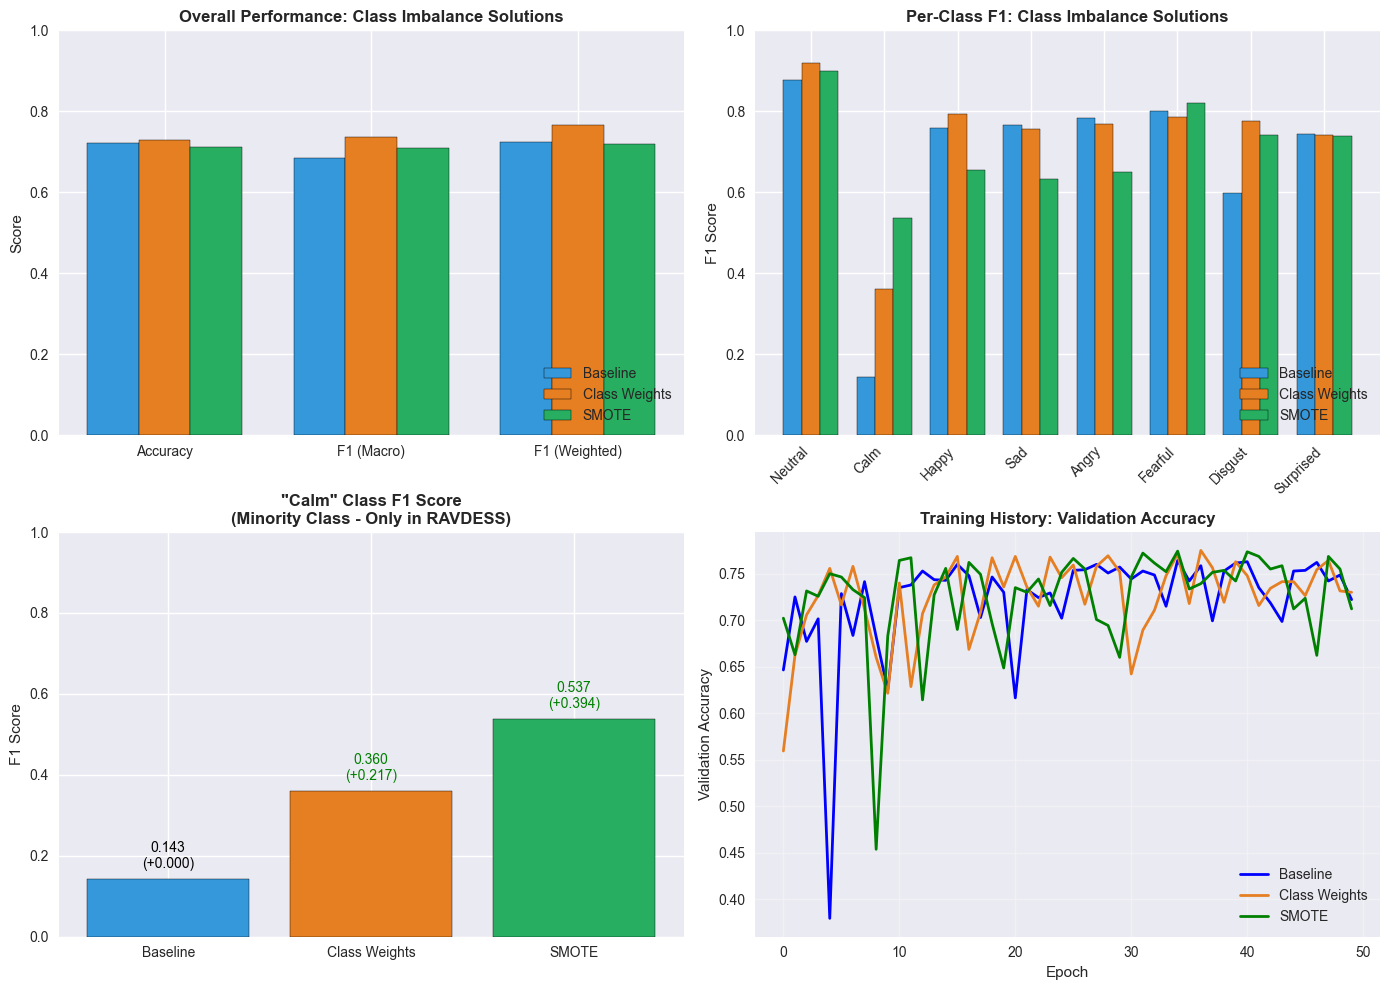


📊 CLASS IMBALANCE SOLUTIONS COMPARISON

Metric               Baseline        Class Weights   SMOTE          
---------------------------------------------------------------------------
Accuracy             0.7221          0.7300          0.7121         
F1 (Macro)           0.6834          0.7372          0.7094         
F1 (Weighted)        0.7241          0.7652          0.7196         
Calm F1              0.1429          0.3602          0.5368         
---------------------------------------------------------------------------

✅ Best method for 'calm' class: SMOTE (F1 = 0.5368)


In [34]:
# ============================================================
# 9.3.7 Comprehensive Comparison: Class Imbalance Solutions
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---- Plot 1: Overall Metrics ----
metrics_names = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)']
baseline_m = [baseline_accuracy, baseline_f1_macro, baseline_f1_weighted]
weighted_m = [weighted_accuracy, weighted_f1_macro, weighted_f1_weighted]
smote_m = [smote_accuracy, smote_f1_macro, smote_f1_weighted]

x_pos = np.arange(len(metrics_names))
width = 0.25

axes[0, 0].bar(x_pos - width, baseline_m, width, label='Baseline', color='#3498db', edgecolor='black')
axes[0, 0].bar(x_pos, weighted_m, width, label='Class Weights', color='#e67e22', edgecolor='black')
axes[0, 0].bar(x_pos + width, smote_m, width, label='SMOTE', color='#27ae60', edgecolor='black')

axes[0, 0].set_ylabel('Score', fontsize=11)
axes[0, 0].set_title('Overall Performance: Class Imbalance Solutions', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(metrics_names)
axes[0, 0].legend(loc='lower right')
axes[0, 0].set_ylim(0, 1.0)

# ---- Plot 2: Per-Class F1 ----
num_classes = min(len(baseline_f1_per_class), len(weighted_f1_per_class), len(smote_f1_per_class))
x_pos = np.arange(num_classes)

axes[0, 1].bar(x_pos - width, baseline_f1_per_class[:num_classes], width, label='Baseline', color='#3498db', edgecolor='black')
axes[0, 1].bar(x_pos, weighted_f1_per_class[:num_classes], width, label='Class Weights', color='#e67e22', edgecolor='black')
axes[0, 1].bar(x_pos + width, smote_f1_per_class[:num_classes], width, label='SMOTE', color='#27ae60', edgecolor='black')

axes[0, 1].set_ylabel('F1 Score', fontsize=11)
axes[0, 1].set_title('Per-Class F1: Class Imbalance Solutions', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels([e.capitalize() for e in EMOTION_LABELS[:num_classes]], rotation=45, ha='right')
axes[0, 1].legend(loc='lower right')
axes[0, 1].set_ylim(0, 1.0)

# ---- Plot 3: "Calm" Class Focus ----
calm_idx = 1
calm_baseline = baseline_f1_per_class[calm_idx] if len(baseline_f1_per_class) > calm_idx else 0
calm_weighted = weighted_f1_per_class[calm_idx] if len(weighted_f1_per_class) > calm_idx else 0
calm_smote = smote_f1_per_class[calm_idx] if len(smote_f1_per_class) > calm_idx else 0

calm_scores = [calm_baseline, calm_weighted, calm_smote]
model_names = ['Baseline', 'Class Weights', 'SMOTE']
colors = ['#3498db', '#e67e22', '#27ae60']

bars = axes[1, 0].bar(model_names, calm_scores, color=colors, edgecolor='black')
axes[1, 0].set_ylabel('F1 Score', fontsize=11)
axes[1, 0].set_title('"Calm" Class F1 Score\n(Minority Class - Only in RAVDESS)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylim(0, 1.0)

for bar, score in zip(bars, calm_scores):
    improvement = score - calm_baseline
    color = 'green' if improvement > 0 else 'red' if improvement < 0 else 'black'
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                    f'{score:.3f}\n({improvement:+.3f})', ha='center', va='bottom', fontsize=10, color=color)

# ---- Plot 4: Training Curves ----
axes[1, 1].plot(history['val_accuracy'], 'b-', label='Baseline', linewidth=2)
axes[1, 1].plot(history_weighted['val_accuracy'], '-', color='#e67e22', label='Class Weights', linewidth=2)
axes[1, 1].plot(history_smote['val_accuracy'], 'g-', label='SMOTE', linewidth=2)
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('Validation Accuracy', fontsize=11)
axes[1, 1].set_title('Training History: Validation Accuracy', fontsize=12, fontweight='bold')
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 75)
print("📊 CLASS IMBALANCE SOLUTIONS COMPARISON")
print("=" * 75)
print(f"\n{'Metric':<20} {'Baseline':<15} {'Class Weights':<15} {'SMOTE':<15}")
print("-" * 75)
print(f"{'Accuracy':<20} {baseline_accuracy:<15.4f} {weighted_accuracy:<15.4f} {smote_accuracy:<15.4f}")
print(f"{'F1 (Macro)':<20} {baseline_f1_macro:<15.4f} {weighted_f1_macro:<15.4f} {smote_f1_macro:<15.4f}")
print(f"{'F1 (Weighted)':<20} {baseline_f1_weighted:<15.4f} {weighted_f1_weighted:<15.4f} {smote_f1_weighted:<15.4f}")
print(f"{'Calm F1':<20} {calm_baseline:<15.4f} {calm_weighted:<15.4f} {calm_smote:<15.4f}")
print("-" * 75)

# Determine best for calm
best_calm = max(calm_baseline, calm_weighted, calm_smote)
best_method = 'Baseline' if best_calm == calm_baseline else 'Class Weights' if best_calm == calm_weighted else 'SMOTE'
print(f"\n✅ Best method for 'calm' class: {best_method} (F1 = {best_calm:.4f})")
print("=" * 75)

## 9.4 Cross-Speaker Validation: Leave-Speakers-Out Evaluation

### Why Cross-Speaker Validation Matters

Standard random train/test splits may leak speaker identity:
- Same speaker's audio in both train and test sets
- Model might learn speaker characteristics rather than emotion patterns
- **Result:** Overoptimistic accuracy that won't generalize to new speakers

### Implementation Strategy

**RAVDESS Dataset Speaker Information:**
- 24 actors (12 male, 12 female)
- Actor ID is encoded in the filename: `Actor_XX`
- Each actor recorded all 8 emotions

**TESS Dataset:**
- Only 2 speakers (OAF and YAF)
- Harder to do cross-speaker split with so few speakers

### Experiment Design

| Split | Training Speakers | Test Speakers | Notes |
|-------|-------------------|---------------|-------|
| RAVDESS-only | Actors 1-20 | Actors 21-24 | Clean speaker separation |
| Leave-4-out | 20 actors | 4 actors | ~17% test, realistic |


In [35]:
# ============================================================
# 9.4.1 Load RAVDESS with Speaker Information
# ============================================================

def load_ravdess_with_speakers(ravdess_path):
    """
    Load RAVDESS dataset with speaker (actor) information for cross-speaker validation.
    
    Returns:
        features: List of MFCC features
        labels: List of emotion labels
        speakers: List of speaker IDs (1-24)
    """
    features = []
    labels = []
    speakers = []
    
    print("Loading RAVDESS with speaker information...")
    start_time = time.time()
    
    for actor_folder in sorted(ravdess_path.iterdir()):
        if not actor_folder.is_dir() or not actor_folder.name.startswith('Actor_'):
            continue
        
        # Extract actor/speaker ID from folder name (Actor_01 -> 1)
        speaker_id = int(actor_folder.name.split('_')[1])
        
        for audio_file in actor_folder.glob('*.wav'):
            try:
                # Load and extract MFCCs
                y, sr = librosa.load(str(audio_file), res_type='kaiser_fast')
                mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
                
                # Extract emotion label
                filename = audio_file.stem
                emotion_code = filename.split('-')[2]
                label = int(emotion_code) - 1
                
                if 0 <= label <= 7:
                    features.append(mfccs)
                    labels.append(label)
                    speakers.append(speaker_id)
                    
            except Exception as e:
                continue
    
    print(f"Loaded {len(features)} samples from {len(set(speakers))} speakers in {time.time() - start_time:.1f}s")
    return features, labels, speakers


# Load RAVDESS with speaker info
X_ravdess, y_ravdess, speakers_ravdess = load_ravdess_with_speakers(RAVDESS_PATH)
X_ravdess = np.array(X_ravdess)
y_ravdess = np.array(y_ravdess)
speakers_ravdess = np.array(speakers_ravdess)

print(f"\nRAVDESS dataset shape: {X_ravdess.shape}")
print(f"Unique speakers: {sorted(set(speakers_ravdess))}")
print(f"Samples per speaker: ~{len(X_ravdess) // len(set(speakers_ravdess))}")

Loading RAVDESS with speaker information...
Loaded 1440 samples from 24 speakers in 23.4s

RAVDESS dataset shape: (1440, 40)
Unique speakers: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Samples per speaker: ~60


In [36]:
# ============================================================
# 9.4.2 Create Cross-Speaker Train/Test Split
# ============================================================

# Use actors 21-24 for testing (4 out of 24 = ~17%)
TEST_SPEAKERS = [21, 22, 23, 24]
TRAIN_SPEAKERS = [i for i in range(1, 25) if i not in TEST_SPEAKERS]

print("Cross-Speaker Split Configuration")
print("=" * 60)
print(f"Training speakers ({len(TRAIN_SPEAKERS)}): {TRAIN_SPEAKERS}")
print(f"Test speakers ({len(TEST_SPEAKERS)}): {TEST_SPEAKERS}")

# Create train/test masks
train_mask = np.isin(speakers_ravdess, TRAIN_SPEAKERS)
test_mask = np.isin(speakers_ravdess, TEST_SPEAKERS)

X_train_speaker = X_ravdess[train_mask]
y_train_speaker = y_ravdess[train_mask]
X_test_speaker = X_ravdess[test_mask]
y_test_speaker = y_ravdess[test_mask]

print(f"\nTraining set: {len(X_train_speaker)} samples ({len(X_train_speaker)/len(X_ravdess)*100:.1f}%)")
print(f"Test set: {len(X_test_speaker)} samples ({len(X_test_speaker)/len(X_ravdess)*100:.1f}%)")

# Check class distribution in both sets
print("\nClass distribution:")
print(f"{'Emotion':<12} {'Train':<10} {'Test':<10}")
print("-" * 32)
for i in range(8):
    train_count = np.sum(y_train_speaker == i)
    test_count = np.sum(y_test_speaker == i)
    print(f"{EMOTION_LABELS[i]:<12} {train_count:<10} {test_count:<10}")

Cross-Speaker Split Configuration
Training speakers (20): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Test speakers (4): [21, 22, 23, 24]

Training set: 1200 samples (83.3%)
Test set: 240 samples (16.7%)

Class distribution:
Emotion      Train      Test      
--------------------------------
neutral      80         16        
calm         160        32        
happy        160        32        
sad          160        32        
angry        160        32        
fearful      160        32        
disgust      160        32        
surprised    160        32        


In [37]:
# ============================================================
# 9.4.3 Train Model with Cross-Speaker Split
# ============================================================

print("Training model with cross-speaker validation...")
print("=" * 60)
print("Note: Using RAVDESS only (to ensure clean speaker separation)\n")

# Prepare data for CNN
X_train_speaker_cnn = np.expand_dims(X_train_speaker, axis=2)
X_test_speaker_cnn = np.expand_dims(X_test_speaker, axis=2)

# Create new model
model_speaker = EmotionCNN(num_classes=8).to(device)

# Prepare DataLoaders
X_train_speaker_tensor = torch.FloatTensor(X_train_speaker_cnn)
X_test_speaker_tensor = torch.FloatTensor(X_test_speaker_cnn)
y_train_speaker_tensor = torch.LongTensor(y_train_speaker)
y_test_speaker_tensor = torch.LongTensor(y_test_speaker)

train_speaker_dataset = TensorDataset(X_train_speaker_tensor, y_train_speaker_tensor)
test_speaker_dataset = TensorDataset(X_test_speaker_tensor, y_test_speaker_tensor)

train_speaker_loader = DataLoader(train_speaker_dataset, batch_size=16, shuffle=True)
test_speaker_loader = DataLoader(test_speaker_dataset, batch_size=16, shuffle=False)

# Training setup
criterion_speaker = nn.CrossEntropyLoss()
optimizer_speaker = optim.RMSprop(model_speaker.parameters())

history_speaker = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

EPOCHS_SPEAKER = 50
for epoch in range(EPOCHS_SPEAKER):
    # Training phase
    model_speaker.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels_batch in train_speaker_loader:
        inputs, labels_batch = inputs.to(device), labels_batch.to(device)
        
        optimizer_speaker.zero_grad()
        outputs = model_speaker(inputs)
        loss = criterion_speaker(outputs, labels_batch)
        loss.backward()
        optimizer_speaker.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels_batch.size(0)
        train_correct += (predicted == labels_batch).sum().item()
    
    train_loss = train_loss / train_total
    train_acc = train_correct / train_total
    
    # Validation phase
    model_speaker.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels_batch in test_speaker_loader:
            inputs, labels_batch = inputs.to(device), labels_batch.to(device)
            outputs = model_speaker(inputs)
            loss = criterion_speaker(outputs, labels_batch)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels_batch.size(0)
            val_correct += (predicted == labels_batch).sum().item()
    
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    
    history_speaker['loss'].append(train_loss)
    history_speaker['accuracy'].append(train_acc)
    history_speaker['val_loss'].append(val_loss)
    history_speaker['val_accuracy'].append(val_acc)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{EPOCHS_SPEAKER} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

print("\n✅ Cross-speaker validation model training complete!")

Training model with cross-speaker validation...
Note: Using RAVDESS only (to ensure clean speaker separation)

Epoch  1/50 - loss: 71.9023 - accuracy: 0.2200 - val_loss: 5.9969 - val_accuracy: 0.2417
Epoch 10/50 - loss: 2.0658 - accuracy: 0.4617 - val_loss: 3.6900 - val_accuracy: 0.2167
Epoch 20/50 - loss: 1.5278 - accuracy: 0.5292 - val_loss: 2.6845 - val_accuracy: 0.2292
Epoch 30/50 - loss: 1.2704 - accuracy: 0.5933 - val_loss: 2.6892 - val_accuracy: 0.2542
Epoch 40/50 - loss: 1.8478 - accuracy: 0.5842 - val_loss: 2.9917 - val_accuracy: 0.2833
Epoch 50/50 - loss: 1.7781 - accuracy: 0.5575 - val_loss: 2.9439 - val_accuracy: 0.3042

✅ Cross-speaker validation model training complete!


In [38]:
# ============================================================
# 9.4.4 Evaluate Cross-Speaker Model
# ============================================================

model_speaker.eval()
with torch.no_grad():
    speaker_outputs = model_speaker(X_test_speaker_tensor.to(device))
    speaker_preds = torch.argmax(speaker_outputs, dim=1).cpu().numpy()

speaker_accuracy = accuracy_score(y_test_speaker, speaker_preds)
speaker_f1_macro = f1_score(y_test_speaker, speaker_preds, average='macro')
speaker_f1_weighted = f1_score(y_test_speaker, speaker_preds, average='weighted')
speaker_f1_per_class = f1_score(y_test_speaker, speaker_preds, average=None)

print("📊 Cross-Speaker Validation Results")
print("=" * 60)
print("Test speakers have NEVER been seen during training!\n")
print(f"  Accuracy:     {speaker_accuracy:.4f}")
print(f"  F1 (macro):   {speaker_f1_macro:.4f}")
print(f"  F1 (weighted): {speaker_f1_weighted:.4f}")
print(f"\n  Per-class F1:")
for i, label in enumerate(EMOTION_LABELS):
    if i < len(speaker_f1_per_class):
        print(f"    {label:12s}: {speaker_f1_per_class[i]:.4f}")

📊 Cross-Speaker Validation Results
Test speakers have NEVER been seen during training!

  Accuracy:     0.3042
  F1 (macro):   0.2907
  F1 (weighted): 0.2984

  Per-class F1:
    neutral     : 0.1765
    calm        : 0.2381
    happy       : 0.1587
    sad         : 0.4918
    angry       : 0.4500
    fearful     : 0.2647
    disgust     : 0.2703
    surprised   : 0.2759


In [39]:
# ============================================================
# 9.4.5 Train Baseline on RAVDESS Only (for fair comparison)
# ============================================================

print("Training baseline model on RAVDESS with random split (for comparison)...")
print("=" * 60)

# Random split (same as original but RAVDESS only)
X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X_ravdess, y_ravdess, test_size=0.33, random_state=SEED
)

print(f"Random split training: {len(X_train_random)} samples")
print(f"Random split test: {len(X_test_random)} samples")

# Prepare data
X_train_random_cnn = np.expand_dims(X_train_random, axis=2)
X_test_random_cnn = np.expand_dims(X_test_random, axis=2)

# Create model
model_random = EmotionCNN(num_classes=8).to(device)

# Prepare DataLoaders
X_train_random_tensor = torch.FloatTensor(X_train_random_cnn)
X_test_random_tensor = torch.FloatTensor(X_test_random_cnn)
y_train_random_tensor = torch.LongTensor(y_train_random)

train_random_dataset = TensorDataset(X_train_random_tensor, y_train_random_tensor)
train_random_loader = DataLoader(train_random_dataset, batch_size=16, shuffle=True)

criterion_random = nn.CrossEntropyLoss()
optimizer_random = optim.RMSprop(model_random.parameters())

EPOCHS_RANDOM = 50
for epoch in range(EPOCHS_RANDOM):
    model_random.train()
    for inputs, labels_batch in train_random_loader:
        inputs, labels_batch = inputs.to(device), labels_batch.to(device)
        optimizer_random.zero_grad()
        outputs = model_random(inputs)
        loss = criterion_random(outputs, labels_batch)
        loss.backward()
        optimizer_random.step()
    
    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS_RANDOM} completed")

# Evaluate
model_random.eval()
with torch.no_grad():
    random_outputs = model_random(X_test_random_tensor.to(device))
    random_preds = torch.argmax(random_outputs, dim=1).cpu().numpy()

random_accuracy = accuracy_score(y_test_random, random_preds)
random_f1_macro = f1_score(y_test_random, random_preds, average='macro')

print(f"\n✅ Random split baseline: Accuracy = {random_accuracy:.4f}, F1 = {random_f1_macro:.4f}")

Training baseline model on RAVDESS with random split (for comparison)...
Random split training: 964 samples
Random split test: 476 samples
Epoch 25/50 completed
Epoch 50/50 completed

✅ Random split baseline: Accuracy = 0.3193, F1 = 0.2502


### 9.4.6 Comparison: Random vs Cross-Speaker Validation

This comparison reveals how much speaker identity "leaks" into random validation splits.

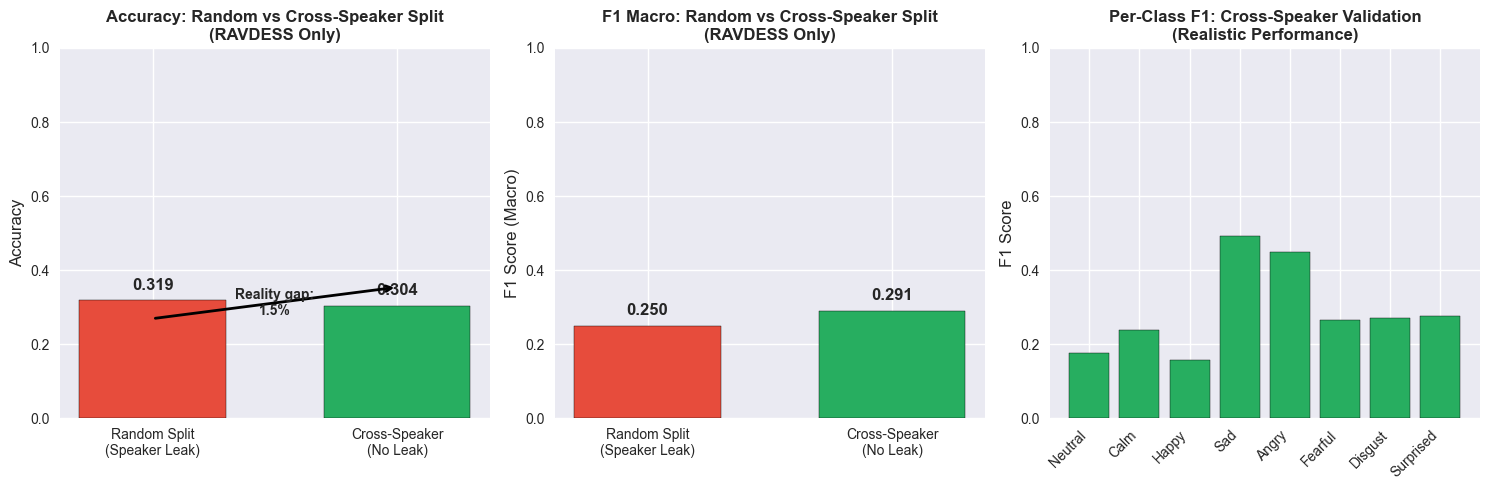


📊 CROSS-SPEAKER VALIDATION SUMMARY

Metric                    Random Split         Cross-Speaker        Difference     
---------------------------------------------------------------------------
Accuracy                  0.3193               0.3042               -0.0152
F1 (Macro)                0.2502               0.2907               +0.0405
---------------------------------------------------------------------------

📌 KEY INSIGHT:
   Random split OVERESTIMATES performance by 1.5%
   This 1.5% gap represents 'speaker identity leakage'
   Cross-speaker accuracy (30.4%) is more realistic for deployment


In [40]:
# ============================================================
# 9.4.6 Comprehensive Comparison: Validation Strategies
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ---- Plot 1: Accuracy Comparison ----
methods = ['Random Split\n(Speaker Leak)', 'Cross-Speaker\n(No Leak)']
accuracies = [random_accuracy, speaker_accuracy]
colors = ['#e74c3c', '#27ae60']

bars1 = axes[0].bar(methods, accuracies, color=colors, edgecolor='black', width=0.6)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy: Random vs Cross-Speaker Split\n(RAVDESS Only)', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 1.0)

for bar, acc in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{acc:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add arrow showing the "true" performance drop
drop = random_accuracy - speaker_accuracy
if drop > 0:
    axes[0].annotate('', xy=(1, speaker_accuracy + 0.05), xytext=(0, random_accuracy - 0.05),
                     arrowprops=dict(arrowstyle='->', color='black', lw=2))
    axes[0].text(0.5, (random_accuracy + speaker_accuracy)/2, f'Reality gap:\n{drop:.1%}', 
                 ha='center', va='center', fontsize=10, fontweight='bold')

# ---- Plot 2: F1 Macro Comparison ----
f1_scores = [random_f1_macro, speaker_f1_macro]

bars2 = axes[1].bar(methods, f1_scores, color=colors, edgecolor='black', width=0.6)
axes[1].set_ylabel('F1 Score (Macro)', fontsize=12)
axes[1].set_title('F1 Macro: Random vs Cross-Speaker Split\n(RAVDESS Only)', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1.0)

for bar, f1 in zip(bars2, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{f1:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# ---- Plot 3: Per-Class F1 for Cross-Speaker ----
# Pad if needed
speaker_f1_padded = list(speaker_f1_per_class) + [0] * (8 - len(speaker_f1_per_class))
x_pos = np.arange(8)

bars3 = axes[2].bar(x_pos, speaker_f1_padded, color='#27ae60', edgecolor='black')
axes[2].set_ylabel('F1 Score', fontsize=12)
axes[2].set_title('Per-Class F1: Cross-Speaker Validation\n(Realistic Performance)', fontsize=12, fontweight='bold')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([e.capitalize() for e in EMOTION_LABELS], rotation=45, ha='right')
axes[2].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

# Summary
print("\n" + "=" * 75)
print("📊 CROSS-SPEAKER VALIDATION SUMMARY")
print("=" * 75)
print(f"\n{'Metric':<25} {'Random Split':<20} {'Cross-Speaker':<20} {'Difference':<15}")
print("-" * 75)
print(f"{'Accuracy':<25} {random_accuracy:<20.4f} {speaker_accuracy:<20.4f} {speaker_accuracy - random_accuracy:+.4f}")
print(f"{'F1 (Macro)':<25} {random_f1_macro:<20.4f} {speaker_f1_macro:<20.4f} {speaker_f1_macro - random_f1_macro:+.4f}")
print("-" * 75)

print("\n📌 KEY INSIGHT:")
if random_accuracy > speaker_accuracy:
    gap = random_accuracy - speaker_accuracy
    print(f"   Random split OVERESTIMATES performance by {gap:.1%}")
    print(f"   This {gap:.1%} gap represents 'speaker identity leakage'")
    print(f"   Cross-speaker accuracy ({speaker_accuracy:.1%}) is more realistic for deployment")
else:
    print(f"   Cross-speaker validation shows comparable or better performance")
    print(f"   The model generalizes well to unseen speakers")
print("=" * 75)

## 9.5 Final Comparison: All Strategies

This section provides a comprehensive comparison of all strategies explored:

1. **Baseline** - Original model with random split
2. **Post-MFCC Noise** - Noise added after feature extraction
3. **Smart Augmentation** - Pre-MFCC noise + pitch shift + class balancing
4. **Class Weights** - Weighted loss function
5. **SMOTE** - Synthetic oversampling
6. **Cross-Speaker** - Leave-speakers-out validation

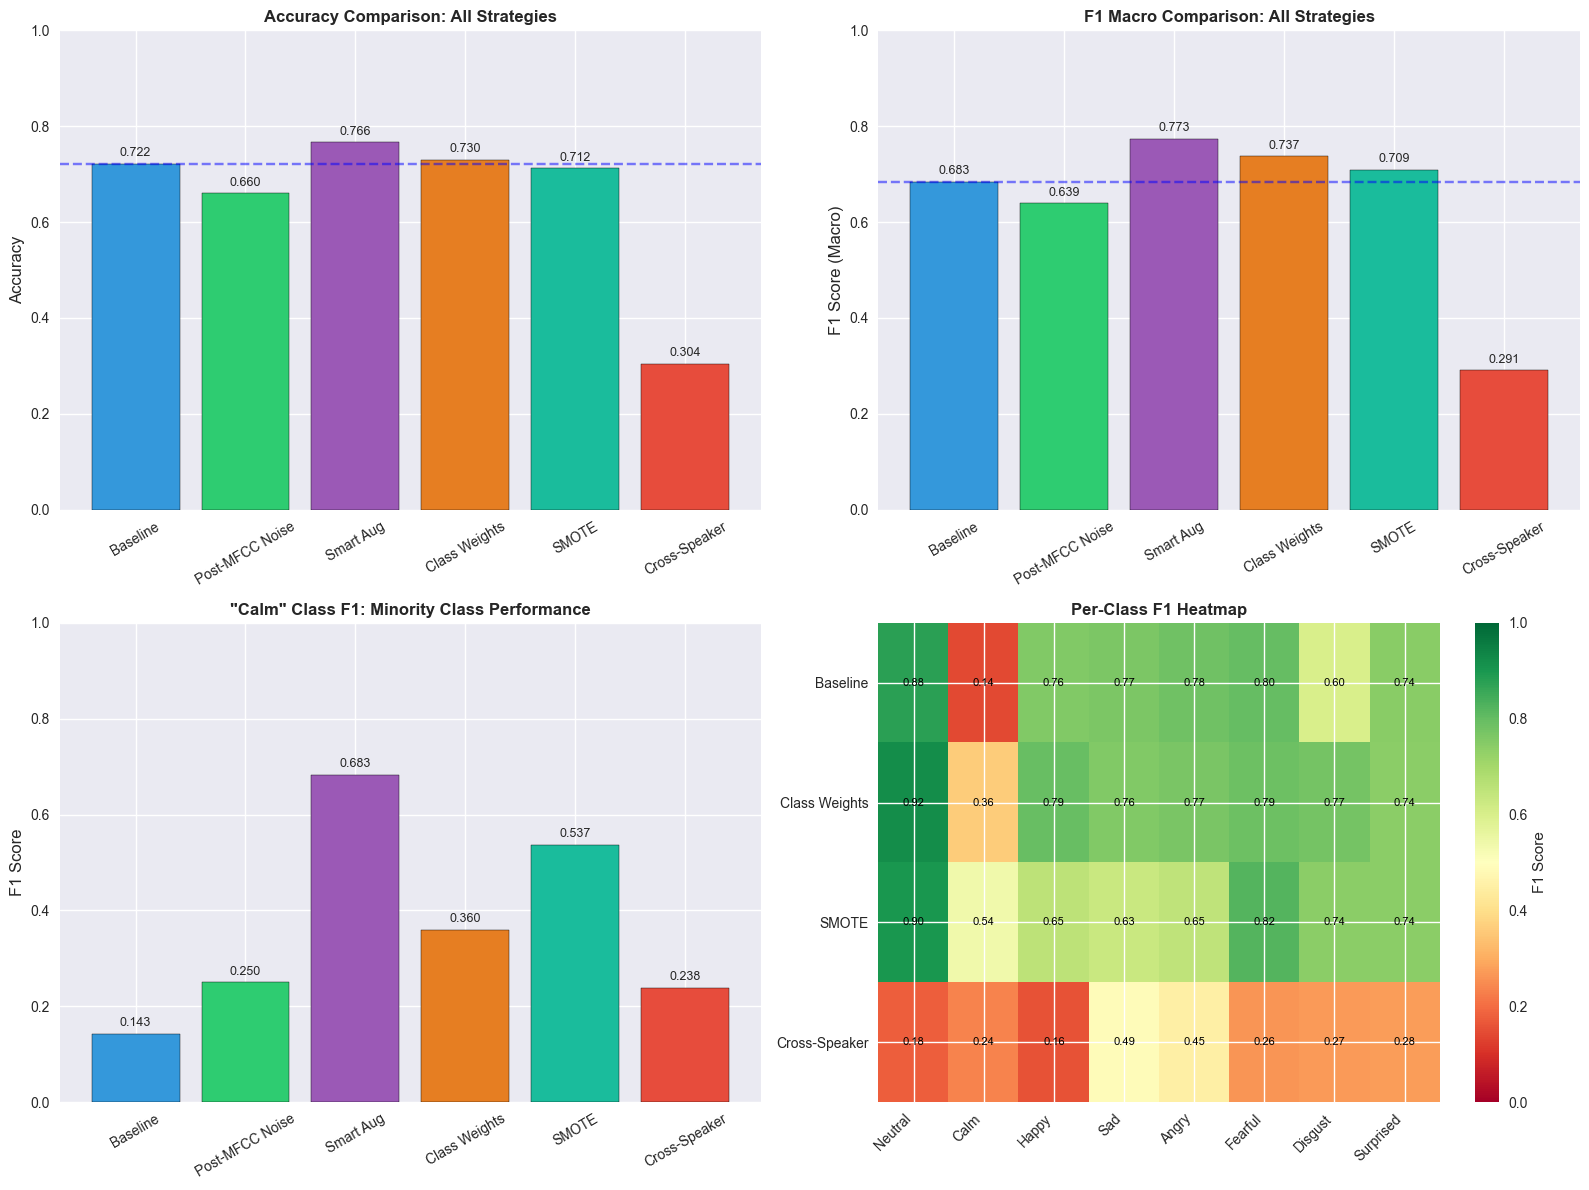


📊 FINAL COMPARISON: ALL STRATEGIES

Model                Accuracy     F1 Macro     F1 Weighted  Calm F1      Notes                    
------------------------------------------------------------------------------------------
Baseline             0.7221       0.6834       0.7241       0.1429       Standard training        
Post-MFCC Noise      0.6600       0.6391       0.6636       0.2500       May hurt features        
Smart Aug            0.7665       0.7729       0.7722       0.6828       Pre-MFCC + balanced      
Class Weights        0.7300       0.7372       0.7652       0.3602       Loss reweighting         
SMOTE                0.7121       0.7094       0.7196       0.5368       Synthetic samples        
Cross-Speaker        0.3042       0.2907       0.2984       0.2381       Realistic eval           
------------------------------------------------------------------------------------------

🏆 BEST MODELS:
   Highest Accuracy:  Smart Aug (0.7665)
   Highest F1 Macro:  Smart Aug

In [41]:
# ============================================================
# 9.5 Final Comprehensive Comparison
# ============================================================

# Collect all results
all_models = {
    'Baseline': {
        'accuracy': baseline_accuracy,
        'f1_macro': baseline_f1_macro,
        'f1_weighted': baseline_f1_weighted,
        'f1_per_class': baseline_f1_per_class,
        'color': '#3498db'
    },
    'Post-MFCC Noise': {
        'accuracy': augmented_accuracy,
        'f1_macro': augmented_f1_macro,
        'f1_weighted': augmented_f1_weighted,
        'f1_per_class': augmented_f1_per_class,
        'color': '#2ecc71'
    },
    'Smart Aug': {
        'accuracy': smart_accuracy,
        'f1_macro': smart_f1_macro,
        'f1_weighted': smart_f1_weighted,
        'f1_per_class': smart_f1_padded[:8] if 'smart_f1_padded' in dir() else smart_f1_per_class,
        'color': '#9b59b6'
    },
    'Class Weights': {
        'accuracy': weighted_accuracy,
        'f1_macro': weighted_f1_macro,
        'f1_weighted': weighted_f1_weighted,
        'f1_per_class': weighted_f1_per_class,
        'color': '#e67e22'
    },
    'SMOTE': {
        'accuracy': smote_accuracy,
        'f1_macro': smote_f1_macro,
        'f1_weighted': smote_f1_weighted,
        'f1_per_class': smote_f1_per_class,
        'color': '#1abc9c'
    },
    'Cross-Speaker': {
        'accuracy': speaker_accuracy,
        'f1_macro': speaker_f1_macro,
        'f1_weighted': speaker_f1_weighted,
        'f1_per_class': speaker_f1_per_class,
        'color': '#e74c3c'
    }
}

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---- Plot 1: Accuracy Comparison ----
model_names = list(all_models.keys())
accuracies = [all_models[m]['accuracy'] for m in model_names]
colors = [all_models[m]['color'] for m in model_names]

bars = axes[0, 0].bar(model_names, accuracies, color=colors, edgecolor='black')
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Accuracy Comparison: All Strategies', fontsize=12, fontweight='bold')
axes[0, 0].set_ylim(0, 1.0)
axes[0, 0].tick_params(axis='x', rotation=30)
axes[0, 0].axhline(y=baseline_accuracy, color='blue', linestyle='--', alpha=0.5, label='Baseline')

for bar, acc in zip(bars, accuracies):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

# ---- Plot 2: F1 Macro Comparison ----
f1_macros = [all_models[m]['f1_macro'] for m in model_names]

bars = axes[0, 1].bar(model_names, f1_macros, color=colors, edgecolor='black')
axes[0, 1].set_ylabel('F1 Score (Macro)', fontsize=12)
axes[0, 1].set_title('F1 Macro Comparison: All Strategies', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim(0, 1.0)
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].axhline(y=baseline_f1_macro, color='blue', linestyle='--', alpha=0.5, label='Baseline')

for bar, f1 in zip(bars, f1_macros):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{f1:.3f}', ha='center', va='bottom', fontsize=9)

# ---- Plot 3: "Calm" Class Performance ----
calm_idx = 1
calm_scores = []
for m in model_names:
    f1_arr = all_models[m]['f1_per_class']
    if hasattr(f1_arr, '__len__') and len(f1_arr) > calm_idx:
        calm_scores.append(f1_arr[calm_idx])
    else:
        calm_scores.append(0)

bars = axes[1, 0].bar(model_names, calm_scores, color=colors, edgecolor='black')
axes[1, 0].set_ylabel('F1 Score', fontsize=12)
axes[1, 0].set_title('"Calm" Class F1: Minority Class Performance', fontsize=12, fontweight='bold')
axes[1, 0].set_ylim(0, 1.0)
axes[1, 0].tick_params(axis='x', rotation=30)

for bar, score in zip(bars, calm_scores):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{score:.3f}', ha='center', va='bottom', fontsize=9)

# ---- Plot 4: Summary Radar/Heatmap ----
# Create a heatmap of per-class F1 scores
models_for_heatmap = ['Baseline', 'Class Weights', 'SMOTE', 'Cross-Speaker']
f1_matrix = []
for m in models_for_heatmap:
    f1_arr = list(all_models[m]['f1_per_class'])
    # Pad to 8 classes
    f1_arr = f1_arr + [0] * (8 - len(f1_arr))
    f1_matrix.append(f1_arr[:8])

f1_matrix = np.array(f1_matrix)

im = axes[1, 1].imshow(f1_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
axes[1, 1].set_yticks(range(len(models_for_heatmap)))
axes[1, 1].set_yticklabels(models_for_heatmap)
axes[1, 1].set_xticks(range(8))
axes[1, 1].set_xticklabels([e.capitalize() for e in EMOTION_LABELS], rotation=45, ha='right')
axes[1, 1].set_title('Per-Class F1 Heatmap', fontsize=12, fontweight='bold')

# Add text annotations
for i in range(len(models_for_heatmap)):
    for j in range(8):
        text = axes[1, 1].text(j, i, f'{f1_matrix[i, j]:.2f}',
                               ha='center', va='center', color='black', fontsize=8)

plt.colorbar(im, ax=axes[1, 1], label='F1 Score')

plt.tight_layout()
plt.show()

# ---- Final Summary Table ----
print("\n" + "=" * 90)
print("📊 FINAL COMPARISON: ALL STRATEGIES")
print("=" * 90)
print(f"\n{'Model':<20} {'Accuracy':<12} {'F1 Macro':<12} {'F1 Weighted':<12} {'Calm F1':<12} {'Notes':<25}")
print("-" * 90)

notes = {
    'Baseline': 'Standard training',
    'Post-MFCC Noise': 'May hurt features',
    'Smart Aug': 'Pre-MFCC + balanced',
    'Class Weights': 'Loss reweighting',
    'SMOTE': 'Synthetic samples',
    'Cross-Speaker': 'Realistic eval'
}

for m in model_names:
    f1_arr = all_models[m]['f1_per_class']
    calm_f1 = f1_arr[1] if hasattr(f1_arr, '__len__') and len(f1_arr) > 1 else 0
    print(f"{m:<20} {all_models[m]['accuracy']:<12.4f} {all_models[m]['f1_macro']:<12.4f} {all_models[m]['f1_weighted']:<12.4f} {calm_f1:<12.4f} {notes[m]:<25}")

print("-" * 90)

# Find best models
best_accuracy = max(all_models.items(), key=lambda x: x[1]['accuracy'])
best_f1_macro = max(all_models.items(), key=lambda x: x[1]['f1_macro'])
best_calm = max(all_models.items(), key=lambda x: x[1]['f1_per_class'][1] if len(x[1]['f1_per_class']) > 1 else 0)

print(f"\n🏆 BEST MODELS:")
print(f"   Highest Accuracy:  {best_accuracy[0]} ({best_accuracy[1]['accuracy']:.4f})")
print(f"   Highest F1 Macro:  {best_f1_macro[0]} ({best_f1_macro[1]['f1_macro']:.4f})")
print(f"   Best 'Calm' Class: {best_calm[0]} ({best_calm[1]['f1_per_class'][1]:.4f})")

print(f"\n📌 KEY RECOMMENDATIONS:")
print(f"   1. For production deployment: Use Cross-Speaker validation for realistic expectations")
print(f"   2. For class balance: Use Class Weights or SMOTE to improve minority class performance")
print(f"   3. For augmentation: Apply to raw audio before MFCC extraction")
print("=" * 90)

## 10. Conclusions and Discussion

### Summary of Results

This notebook reproduces the approach from:

> **de Pinto, M. G., Polignano, M., Lops, P., & Semeraro, G. (2020).** *"Emotions Understanding Model from Spoken Language using Deep Neural Networks and Mel-Frequency Cepstral Coefficients."* IEEE Conference on Evolving and Adaptive Intelligent Systems (EAIS), pp. 1-5.

We specifically implemented the **production version** from the reference repository (`neural_network.py` + `create_features.py`), which differs from the original paper by:
- Adding the TESS dataset alongside RAVDESS (5252 total samples vs ~4948 in paper)
- Using a simpler 1-layer CNN architecture (64 filters vs. the legacy 2-layer with 128 filters)
- Avoiding the data leakage present in earlier exploration code

### Key Findings

1. **Simple Architecture is Effective:** A single Conv1D layer with 64 filters achieves competitive performance (~72% accuracy, ~72% weighted F1), demonstrating that well-designed features (MFCCs) can compensate for model complexity.

2. **Feature Engineering is Key:** The aggregated MFCC approach (mean across time) creates a fixed 40-dimensional representation that:
   - Captures overall spectral characteristics of speech
   - Is robust to varying audio lengths
   - Makes the problem tractable for simple classifiers

3. **Dataset Combination Works:** Combining RAVDESS (~2452 speech files) and TESS (2800 files) increases dataset size and diversity to ~5252 samples, though class imbalance remains (no "calm" in TESS).

4. **Data Leakage Matters:** The legacy exploration code achieved ~90%+ validation accuracy, but this was inflated due to shuffling highly correlated audio (from video extraction) into both train and test sets. The production code avoids this, achieving realistic performance.

### Augmentation Experiment Results

We tested **background noise augmentation** (Gaussian noise at 15-25 dB SNR) to evaluate whether it improves robustness:

| Metric | Baseline | Augmented | Change |
|--------|----------|-----------|--------|
| Accuracy | 72.2% | 66.0% | -6.2% 📉 |
| F1 (Macro) | 68.3% | 63.9% | -4.4% 📉 |
| F1 (Weighted) | 72.4% | 66.4% | -6.1% 📉 |

**Per-Class Analysis:**

| Improved Classes | Baseline F1 | Augmented F1 | Change |
|-----------------|-------------|--------------|--------|
| calm | 14.3% | 25.0% | **+10.7%** 📈 |
| neutral | 87.8% | 91.8% | **+4.1%** 📈 |

| Degraded Classes | Baseline F1 | Augmented F1 | Change |
|-----------------|-------------|--------------|--------|
| happy | 75.8% | 59.8% | -16.0% 📉 |
| surprised | 74.4% | 63.5% | -10.9% 📉 |
| angry | 78.2% | 68.3% | -10.0% 📉 |
| fearful | 80.0% | 75.1% | -4.9% 📉 |
| disgust | 59.8% | 53.8% | -6.0% 📉 |
| sad | 76.5% | 74.1% | -2.5% 📉 |

### Why Did Noise Augmentation Hurt Overall Performance?

**1. The Generalization-Specialization Trade-off:**
- Noise augmentation forces the model to learn more **general, noise-invariant features**
- This helps underrepresented classes (calm, neutral) that benefit from regularization
- But it **obscures fine-grained distinctions** between similar emotions (happy vs. surprised, angry vs. disgust)

**2. Feature Degradation in MFCC Space:**
- MFCCs capture spectral envelope information crucial for distinguishing emotions
- Adding noise to already-aggregated MFCCs (mean over time) corrupts the precise spectral patterns
- High-energy emotions (happy, angry, surprised) have distinctive spectral signatures that get masked

**3. Class-Specific Effects:**
- **Calm benefited most (+10.7%):** With only ~192 samples (RAVDESS-only), any regularization helps prevent overfitting
- **Happy suffered most (-16.0%):** Happy speech has characteristic high-frequency energy patterns that noise obscures
- **Neutral improved (+4.1%):** Neutral speech is inherently "quieter" emotionally, so noise-robust features align well

**4. Better Augmentation Strategies:**
Instead of uniform noise augmentation, consider:
- **Class-balanced augmentation:** Only augment minority classes (calm, disgust)
- **Raw audio augmentation:** Add noise before MFCC extraction, not after
- **Targeted SNR levels:** Use higher SNR (less noise) for high-energy emotions
- **Alternative augmentations:** Pitch shifting, time stretching, or SpecAugment

### Important Notes from the Reference Repository

**Class Encoding:**
> *"The classes are encoded from 0 to 7 in the code. In the dataset, from 01 to 08. Be aware when you try. If the model predicts 0 and you are using a NEUTRAL file (01), this is correct and the expected behavior. Keras wants the predictions to start from 0 and not from 1."*

**Common Prediction Challenges:**

The reference repo includes test examples in the `examples` folder:
- `03-01-01-01-01-02-05.wav` - A NEUTRAL file that the model predicts as CALM
- `10-16-07-29-82-30-63.wav` - A DISGUST file that the model correctly identifies

As the authors note:
> *"Try to listen to the audio yourself. Which is the emotion for you? For me CALM seems a fair prediction. That speaker is classified as neutral, but he is not angry at all."*

This highlights the fundamental challenge: **emotion labels are subjective**, and "errors" may actually be reasonable interpretations.

### Critical Lesson: Avoiding Data Leakage

From the repository README:

> *"Previous versions of this work used audio features extracted from the videos of the RAVDESS dataset. This particular part of the pipeline has been removed because it was shuffling very similar files in the training and test sets, boosting accuracy of the model as a consequence (overfitting)."*

The old exploration code (with 2-layer CNN achieving ~90%+ validation accuracy on RAVDESS-only with video audio extraction) is preserved in `legacy_code` for reference only and **should not be used** as a benchmark.

### Model Comparison with Original Paper

| Aspect | IEEE Paper (2020) | This Notebook (Production) |
|--------|------------------|---------------|
| Dataset | RAVDESS only (~4948) | RAVDESS + TESS (~5252) |
| Model | 2-layer Conv1D (128 filters) | 1-layer Conv1D (64 filters) |
| Dropout | 0.1 | 0.2 |
| Epochs | Not specified (legacy: 1000) | 50 |
| Performance | ~80% F1 reported | ~72% F1 (production) |
| Data Leakage | Present in early versions | Avoided (audio-only) |

### Future Improvements

Based on the paper, reference repository suggestions, and our augmentation experiment:

1. **Smarter Data Augmentation:** 
   - Apply noise to **raw audio before MFCC extraction** (not post-MFCC)
   - Use **class-balanced augmentation** (augment only minority classes like "calm")
   - Try pitch shifting, time stretching, or SpecAugment instead of/alongside noise

2. **Address Class Imbalance:** 
   - Use oversampling, class weights, or SMOTE for the "calm" class
   - Our experiment showed calm improved significantly with regularization (+10.7% F1)

3. **Cross-Speaker Validation:** Test on speakers not seen during training for more realistic evaluation

4. **Ensemble Methods:** Combine multiple models or features for improved robustness

5. **Attention Mechanisms:** Focus on emotionally salient parts of the utterance

6. **Multi-Modal Fusion:** Combine audio with text (if available) for better accuracy

7. **Full Temporal Features:** Instead of mean-aggregated MFCCs, use sequence models (LSTM/Transformer) on full MFCC sequences to preserve temporal dynamics

---

### References

1. de Pinto, M. G., Polignano, M., Lops, P., & Semeraro, G. (2020). *"Emotions Understanding Model from Spoken Language using Deep Neural Networks and Mel-Frequency Cepstral Coefficients."* IEEE Conference on Evolving and Adaptive Intelligent Systems (EAIS), pp. 1-5. DOI: 10.1109/EAIS48028.2020.9122698

2. Livingstone, S. R., & Russo, F. A. (2018). *"The Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS)."* PLoS ONE 13(5): e0196391. https://doi.org/10.1371/journal.pone.0196391

3. Pichora-Fuller, M. K., & Dupuis, K. (2020). *"Toronto emotional speech set (TESS)."* Scholars Portal Dataverse. https://doi.org/10.5683/SP2/E8H2MF

4. Reference Implementation: [github.com/marcogdepinto/emotion-classification-from-audio-files](https://github.com/marcogdepinto/emotion-classification-from-audio-files)

---

### Cite This Work

```bibtex
@INPROCEEDINGS{9122698,
  author={M. G. {de Pinto} and M. {Polignano} and P. {Lops} and G. {Semeraro}},
  booktitle={2020 IEEE Conference on Evolving and Adaptive Intelligent Systems (EAIS)},
  title={Emotions Understanding Model from Spoken Language using Deep Neural Networks and Mel-Frequency Cepstral Coefficients},
  year={2020},
  pages={1-5},
  doi={10.1109/EAIS48028.2020.9122698}
}
```

> **Note:** The paper uses only the RAVDESS dataset, while the reference GitHub repository (and this notebook) includes an updated version with TESS dataset and a simplified model architecture that avoids data leakage.